# MBRSET Patient-Level Evaluation (MLP with Bayesian Hyperparameter Search)

This notebook performs **patient-level** diabetic retinopathy classification on MBRSET using **MLP with Bayesian hyperparameter optimization**.

## Workflow
1. Load all embeddings (one CSV per embedding model)
2. Create a **single 80/20 patient-level train/test split** (reused for all embeddings)
3. Train **MLP with BayesSearchCV** for:
   - Binary DR tasks (any DR, referable)
4. Hyperparameter search includes:
   - Number of layers (1-5)
   - Neurons per layer (up to 1024)
   - Regularization (alpha), learning rate, etc.
5. Evaluate on **patient-level** (aggregate predictions per patient)
6. Generate:
   - Classification reports
   - Confusion matrices
   - ROC curves (binary tasks)
   - Training dynamics (train vs validation loss)
   
**Note**: This version uses **class-balanced sample weights**.

## Notebook Map (Recommended Run Order)

> Use this as a quick guide to avoid running cells out of context.

### Core path (most users)
1. Setup and configuration (Cells 3â€“5)
2. Load data and helper functions (Cells 7 and 9)
3. Main train/eval (Cell 12)
4. Summary and dynamics (Cells 17 and 19)

### Generalization-first path (recommended for robust selection)
1. Calibrated CV (Cell 13)
2. CV-guided polishing (Cell 14)
3. Robust utility validation (Cell 15)
4. Production self-contained retrain (Cell 22)

### Optional / advanced
- Targeted sweep (Cell 10)
- Experimental production retrain variant (Cell 21)

## 1. Setup and Imports

In [1]:
import os
import copy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    log_loss,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import src.retina_evaluation as reval
from src.retina_benchmark import list_embeddings_csvs
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")

print("Imports complete.")

Imports complete.


## 2. Configuration

In [2]:
# Paths and dataset
PROJECT_ROOT = Path.cwd()
DATASET_NAME = "mbrset"
VIEW = "macula"

# Split configuration - 80/20 train/test
RANDOM_SEED = 42
TRAIN_FRAC = 0.8
TEST_FRAC = 0.2

# Task definitions - BINARY ONLY
BINARY_TASKS = ["task_any_dr", "task_referable"]
BINARY_TASK_MAP = {
    "task_any_dr": "task_any_diab_retino",
    "task_referable": "task_ref_macular",
}

# Model hyperparameters
CPU_COUNT = os.cpu_count() or 1

# Dimensionality Reduction – PCA=128 (more features for larger model)
USE_PCA = True
PCA_N_COMPONENTS = 128

# ——— BAYESIAN HYPERPARAMETER SEARCH CONFIGURATION ———
USE_BAYESIAN_SEARCH = False
N_BAYES_ITER = 30
BAYES_CV_FOLDS = 3

ARCHITECTURE_OPTIONS = [
    (64,),
    (128,),
    (64, 64),
    (128, 128),
    (256, 128),
    (256, 256),
]

SEARCH_SPACE = {
    'hidden_layer_sizes': Integer(0, len(ARCHITECTURE_OPTIONS) - 1),
    'alpha': Categorical([0.0001, 0.001, 0.01]),
    'learning_rate_init': Real(5e-4, 2e-3, prior='log-uniform'),
    'batch_size': Categorical([128]),
}

# ——— WEIGHTING CONFIGURATION ———
WEIGHTING_CONFIG = {
    "binary": {
        "mode": "balanced",
        "manual": {0: 1.0, 1: 1.0},
        "damping_gamma": 1.0,
    },
}
USE_EMBEDDING_TASK_WEIGHT_OVERRIDES = True

MLP_USE_SAMPLE_WEIGHT = True
RUN_WEIGHTED_VERSION = True
RUN_UNWEIGHTED_VERSION = False

# Threshold selection
THRESHOLD_METHOD = "f1"
THRESHOLD_GRID_SIZE = 201

# ——— BASE MLP CONFIG (Run 11: Fix underfitting from R10) ———
# R10 had alpha=0.08 → 8/14 UNDERFITTING (train loss stuck >0.25).
# Fix strategy:
#   - alpha 0.08→0.06: relax L2 to let models learn (between R9=0.05 and R10=0.08)
#   - batch_size 128→64: 2x gradient updates/epoch → helps stuck models converge
#   - Keep good R10 settings: lr=0.0005, patience=50, warmup=20 (3-4x longer training)
MLP_CONFIG_BINARY = {
    "hidden_layer_sizes": (256, 128),
    "alpha": 0.06,
    "learning_rate_init": 0.0005,
    "lr_min": 1e-5,
    "lr_schedule": "cosine",
    "batch_size": 64,
    "max_epochs": 300,
    "patience": 50,
    "min_delta": 1e-4,
    "warmup_epochs": 20,
}

# ——— PER-EMBEDDING OVERRIDES (Run 11: Targeted alpha reduction) ———
# Embeddings that underfitted on BOTH tasks get lowest alpha.
# Embeddings that underfitted on one task get moderate reduction.
# dinov3_vitb16 was GOOD FIT on both → no override needed.
EMBEDDING_OVERRIDES = {
    "dinov3_convnext_base": {"alpha": 0.03},       # R11: underfits BOTH tasks, needs most freedom
    "dinov3_vitb16": {},                             # R11: GOOD FIT on both, use base alpha=0.06
    "RETFound_mae_shanghai": {"alpha": 0.04},        # R11: F1 dropped most (-0.062), underfits any_dr
    "RETFound_mae_natureCFP": {"alpha": 0.03},       # R11: underfits BOTH tasks
    "RETFound_dinov2_shanghai": {"alpha": 0.05},     # R11: borderline underfitting any_dr
    "vit_base": {"alpha": 0.05},                     # R11: underfits any_dr but F1 actually improved
    "convnextv2_base": {"alpha": 0.05},              # R11: borderline underfitting any_dr
}

# Empty configs - Cell 11 sweep populates at runtime
WEIGHTING_OVERRIDES_CONFIG = {}
THRESHOLD_OVERRIDES_CONFIG = {}

def resolve_config(emb_stem):
    """Merge base config with per-embedding overrides."""
    base = MLP_CONFIG_BINARY.copy()
    matched = None
    for pattern, overrides in EMBEDDING_OVERRIDES.items():
        if pattern in emb_stem:
            if overrides:
                base.update(overrides)
                matched = pattern
            break
    return base, matched

# Output configuration
RESULTS_DIR = PROJECT_ROOT / "results" / "mbrset_patient_eval"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
SAVE_PLOTS = True

print(f"Dataset: {DATASET_NAME}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Split: Train={TRAIN_FRAC:.0%}, Test={TEST_FRAC:.0%}")
print(f"PCA: {PCA_N_COMPONENTS} components")
print(f"Threshold method: {THRESHOLD_METHOD} (grid={THRESHOLD_GRID_SIZE})")
print(f"Per-embedding weight overrides: {'ENABLED' if USE_EMBEDDING_TASK_WEIGHT_OVERRIDES else 'DISABLED'}")
print(f"Architecture: {MLP_CONFIG_BINARY['hidden_layer_sizes']}, alpha={MLP_CONFIG_BINARY['alpha']}, lr={MLP_CONFIG_BINARY['learning_rate_init']}, schedule={MLP_CONFIG_BINARY['lr_schedule']}")
print(f"Batch size: {MLP_CONFIG_BINARY['batch_size']}")
print(f"Max epochs: {MLP_CONFIG_BINARY['max_epochs']}, Patience: {MLP_CONFIG_BINARY['patience']}, Warmup: {MLP_CONFIG_BINARY['warmup_epochs']}")
print(f"\nPer-embedding alpha overrides:")
for k, v in EMBEDDING_OVERRIDES.items():
    if v:
        print(f"  {k}: alpha={v.get('alpha', 'base')}")
    else:
        print(f"  {k}: (base alpha={MLP_CONFIG_BINARY['alpha']})")

Dataset: mbrset
Results directory: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval
Random seed: 42
Split: Train=80%, Test=20%
PCA: 128 components
Threshold method: f1 (grid=201)
Per-embedding weight overrides: ENABLED
Architecture: (256, 128), alpha=0.06, lr=0.0005, schedule=cosine
Batch size: 64
Max epochs: 300, Patience: 50, Warmup: 20

Per-embedding alpha overrides:
  dinov3_convnext_base: alpha=0.03
  dinov3_vitb16: (base alpha=0.06)
  RETFound_mae_shanghai: alpha=0.04
  RETFound_mae_natureCFP: alpha=0.03
  RETFound_dinov2_shanghai: alpha=0.05
  vit_base: alpha=0.05
  convnextv2_base: alpha=0.05


## 3. Load Embeddings and Create Patient-Level Split

In [3]:
# Get paths
embed_dir = PROJECT_ROOT / "data" / f"{DATASET_NAME}_embeddings"
labels_path = embed_dir / f"{DATASET_NAME}_labels" / f"labels_{DATASET_NAME}.csv"

# List all embedding files
embedding_files = list_embeddings_csvs(embed_dir)
if not embedding_files:
    raise FileNotFoundError(f"No embedding CSV files found under {embed_dir}")

print(f"Found {len(embedding_files)} embedding files:")
for i, emb in enumerate(embedding_files):
    print(f"  {i}: {emb.name}")

# Load first embedding to create the split
base_ds = load_retina_embeddings_dataset(
    dataset=DATASET_NAME,
    embeddings_csv_path=embedding_files[0],
    labels_csv_path=labels_path,
    view=VIEW,
)

# Create 80/20 patient-level train/test split (stratified by task_any_dr)
patient_split = reval.make_patient_split(
    df=base_ds.df,
    group_col="patient_id",
    label_col="task_any_dr",
    val_frac=TEST_FRAC,
    seed=RANDOM_SEED,
)

# Extract patient IDs (as str for consistent dtype)
train_patient_ids = set(str(pid) for pid in patient_split.train_patient_ids)
test_patient_ids = set(str(pid) for pid in patient_split.val_patient_ids)

total = len(train_patient_ids) + len(test_patient_ids)
print(f"\nPatient Split (80/20):")
print(f"  Train patients: {len(train_patient_ids)} ({len(train_patient_ids)/total:.0%})")
print(f"  Test patients:  {len(test_patient_ids)} ({len(test_patient_ids)/total:.0%})")
print(f"  Total: {total}")

# Save split for reproducibility
split_info = pd.DataFrame({
    "patient_id": list(train_patient_ids) + list(test_patient_ids),
    "split": ["train"] * len(train_patient_ids) + ["test"] * len(test_patient_ids),
})
split_info.to_csv(RESULTS_DIR / "patient_split.csv", index=False)
print(f"Saved split to: {RESULTS_DIR / 'patient_split.csv'}")

Found 7 embedding files:
  0: Embeddings_convnextv2_base_mbrset.csv
  1: Embeddings_mbrset_dinov3_convnext_base.csv
  2: Embeddings_mbrset_dinov3_vitb16.csv
  3: Embeddings_mbrset_RETFound_dinov2_shanghai.csv
  4: Embeddings_mbrset_RETFound_mae_natureCFP.csv
  5: Embeddings_mbrset_RETFound_mae_shanghai.csv
  6: Embeddings_vit_base_mbrset.csv

Patient Split (80/20):
  Train patients: 1032 (80%)
  Test patients:  259 (20%)
  Total: 1291
Saved split to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval\patient_split.csv


## 4. Helper Functions for Patient-Level Aggregation

In [4]:
from sklearn.utils.class_weight import compute_class_weight
import math


def aggregate_patient_predictions(df, group_col="patient_id"):
    """
    Aggregate image-level predictions to patient-level by taking the majority vote
    for class labels and averaging probabilities.
    """
    patient_groups = []
    
    for patient_id, group in df.groupby(group_col):
        y_pred_patient = group["y_pred"].mode()[0] if len(group["y_pred"].mode()) > 0 else group["y_pred"].iloc[0]
        y_proba_patient = group["y_proba"].mean()
        y_true_patient = group["y_true"].mode()[0] if len(group["y_true"].mode()) > 0 else group["y_true"].iloc[0]
        
        patient_groups.append({
            "patient_id": patient_id,
            "y_true": y_true_patient,
            "y_pred": y_pred_patient,
            "y_proba": y_proba_patient,
            "n_images": len(group),
        })
    
    return pd.DataFrame(patient_groups)


def compute_balanced_weights(y, damping_gamma=0.7):
    """Compute balanced sample weights with damping."""
    y = np.asarray(y)
    if y.size == 0:
        return np.asarray([], dtype=np.float32)
    classes = np.unique(y)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    if damping_gamma is not None and float(damping_gamma) != 1.0:
        class_weights = class_weights ** float(damping_gamma)
    weight_map = {int(c): float(w) for c, w in zip(classes, class_weights)}
    sample_weights = np.array([weight_map[int(lbl)] for lbl in y], dtype=np.float32)
    mean_w = float(np.mean(sample_weights))
    if mean_w > 0:
        sample_weights = sample_weights / mean_w
    return sample_weights


def compute_class_weight_mapping(y, mode="balanced", manual_class_weight=None, damping_gamma=1.0):
    """Return a {class_label: weight} mapping."""
    y = np.asarray(y)
    classes = np.unique(y)
    if classes.size == 0:
        return {}
    if mode == "none":
        mapping = {int(c): 1.0 for c in classes}
    elif mode == "manual":
        manual_class_weight = manual_class_weight or {}
        mapping = {int(c): float(manual_class_weight.get(int(c), 1.0)) for c in classes}
    elif mode == "balanced":
        w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
        mapping = {int(c): float(wi) for c, wi in zip(classes, w)}
    else:
        raise ValueError(f"Unknown weighting mode: {mode}")
    if damping_gamma is not None and float(damping_gamma) != 1.0:
        gamma = float(damping_gamma)
        mapping = {c: float(w ** gamma) for c, w in mapping.items()}
    return mapping


def compute_sample_weights(y, class_weight_mapping, normalize=True):
    """Convert a {class: weight} mapping to per-sample weights."""
    y = np.asarray(y)
    if y.size == 0:
        return np.asarray([], dtype=np.float32)
    sw = np.array([class_weight_mapping.get(int(lbl), 1.0) for lbl in y], dtype=np.float32)
    if normalize and sw.size:
        mean_w = float(np.mean(sw))
        if mean_w > 0:
            sw = sw / mean_w
    return sw


def safe_fit_with_optional_sample_weight(estimator, X, y, sample_weight=None):
    """Fit with sample_weight if supported; otherwise fall back to unweighted fit."""
    if sample_weight is None:
        estimator.fit(X, y)
        return False
    try:
        estimator.fit(X, y, sample_weight=sample_weight)
        return True
    except TypeError:
        estimator.fit(X, y)
        return False


def find_optimal_threshold(y_true, y_proba, method="youden", grid_size=99):
    """Find optimal binary classification threshold."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if y_true.size == 0:
        return 0.5
    if method == "youden":
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        j_scores = tpr - fpr
        best_idx = int(np.argmax(j_scores))
        return float(thresholds[best_idx])
    if method == "f1":
        from sklearn.metrics import f1_score
        grid_size = max(11, min(int(grid_size), 1001))
        thresholds = np.linspace(0.01, 0.99, grid_size)
        best_t, best_f1 = 0.5, -1.0
        for t in thresholds:
            y_pred = (y_proba >= t).astype(int)
            f1 = float(f1_score(y_true, y_pred, zero_division=0))
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)
        return best_t
    raise ValueError(f"Unknown threshold method: {method}")


def weighted_log_loss(y_true, y_proba, labels, sample_weight=None):
    """Compute log loss with optional sample weights."""
    return log_loss(y_true, y_proba, labels=labels, sample_weight=sample_weight)


# ——— COSINE LR SCHEDULE ———

def cosine_lr(epoch, max_epochs, lr_init, lr_min=1e-5, warmup_epochs=10):
    """
    Cosine annealing learning rate with linear warmup.
    
    During warmup (epoch <= warmup_epochs): linear ramp from lr_min to lr_init.
    After warmup: cosine decay from lr_init to lr_min.
    """
    if epoch <= warmup_epochs:
        return lr_min + (lr_init - lr_min) * (epoch / max(1, warmup_epochs))
    progress = (epoch - warmup_epochs) / max(1, max_epochs - warmup_epochs)
    return lr_min + 0.5 * (lr_init - lr_min) * (1 + math.cos(math.pi * progress))


def train_mlp_with_schedule(X_train, y_train, X_val, y_val, mlp_cfg,
                             sample_weight_train=None, sample_weight_val=None,
                             random_seed=42):
    """
    Train MLPClassifier with cosine LR schedule, warmup, and manual early stopping.
    
    Uses warm_start=True with max_iter=1 for epoch-by-epoch control.
    Modifies sklearn's internal optimizer lr each epoch for cosine annealing.
    
    Returns:
        (best_model, best_epoch, train_losses, val_losses)
    """
    lr_init = mlp_cfg["learning_rate_init"]
    lr_min = mlp_cfg.get("lr_min", 1e-5)
    lr_schedule = mlp_cfg.get("lr_schedule", "constant")
    warmup = mlp_cfg.get("warmup_epochs", 0)
    max_epochs = mlp_cfg["max_epochs"]
    patience = mlp_cfg["patience"]
    min_delta = mlp_cfg.get("min_delta", 1e-4)

    # Set epoch-1 lr for correct warmup start
    epoch1_lr = cosine_lr(1, max_epochs, lr_init, lr_min, warmup) if lr_schedule == "cosine" else lr_init

    mlp = MLPClassifier(
        hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
        alpha=mlp_cfg["alpha"],
        learning_rate_init=epoch1_lr,
        batch_size=mlp_cfg["batch_size"],
        max_iter=1,
        warm_start=True,
        early_stopping=False,
        random_state=random_seed,
    )

    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_epoch = 0
    best_model = None
    patience_counter = 0
    labels = np.unique(np.concatenate([y_train, y_val]))

    for epoch in range(1, max_epochs + 1):
        # Cosine LR schedule with warmup
        if lr_schedule == "cosine" and epoch > 1 and hasattr(mlp, '_optimizer'):
            new_lr = cosine_lr(epoch, max_epochs, lr_init, lr_min, warmup)
            mlp._optimizer.learning_rate = new_lr

        safe_fit_with_optional_sample_weight(mlp, X_train, y_train, sample_weight=sample_weight_train)

        train_proba = mlp.predict_proba(X_train)
        val_proba = mlp.predict_proba(X_val)

        tr_loss = float(weighted_log_loss(y_train, train_proba, labels=labels, sample_weight=sample_weight_train))
        va_loss = float(weighted_log_loss(y_val, val_proba, labels=labels, sample_weight=sample_weight_val))

        train_losses.append(tr_loss)
        val_losses.append(va_loss)

        if va_loss < best_val_loss - min_delta:
            best_val_loss = va_loss
            best_epoch = epoch
            best_model = copy.deepcopy(mlp)
            patience_counter = 0
        elif epoch > warmup:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_model, best_epoch, train_losses, val_losses


# ——— WRAPPER CLASS FOR BAYESIAN SEARCH ———
from sklearn.base import BaseEstimator, ClassifierMixin

class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    """Wrapper for MLPClassifier that converts integer architecture indices to tuples."""
    def __init__(self, hidden_layer_sizes=0, alpha=0.01, learning_rate_init=0.001, 
                 batch_size=64, max_iter=400, early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=10, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None
    
    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes
    
    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch, alpha=self.alpha,
            learning_rate_init=self.learning_rate_init, batch_size=self.batch_size,
            max_iter=self.max_iter, early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state, warm_start=self.warm_start,
        )
        if sample_weight is not None:
            self._mlp.fit(X, y, sample_weight=sample_weight)
        else:
            self._mlp.fit(X, y)
        self.classes_ = self._mlp.classes_
        self.n_iter_ = self._mlp.n_iter_
        self.loss_ = self._mlp.loss_
        self.best_loss_ = self._mlp.best_loss_ if hasattr(self._mlp, 'best_loss_') else None
        return self
    
    def predict(self, X):
        return self._mlp.predict(X)
    
    def predict_proba(self, X):
        return self._mlp.predict_proba(X)
    
    def score(self, X, y, sample_weight=None):
        return self._mlp.score(X, y, sample_weight=sample_weight)


def plot_confusion_matrix(cm, title, save_path=None, show=True):
    """Plot confusion matrix."""
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    im = ax.imshow(cm, cmap="viridis", interpolation="nearest")
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis="both", labelsize=9)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_label("Count", fontsize=9)
    thresh = cm.max() / 2.0 if cm.size else 0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f"{val}", ha="center", va="center",
                color="white" if val > thresh else "black", fontsize=10, fontweight="bold")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_roc_curve(fpr, tpr, auc, title, save_path=None, show=True):
    """Plot ROC curve."""
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = Normalize(vmin=0.0, vmax=1.0)
    lc = LineCollection(segments, cmap="plasma", norm=norm)
    lc.set_array(fpr)
    lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0, 1], [0, 1], linestyle="--", color="#666", linewidth=1.2, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{title}\nAUC = {auc:.3f}", fontsize=11, pad=12)
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.legend(loc="lower right", fontsize=9)
    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("FPR", fontsize=9)
    cbar.ax.tick_params(labelsize=9)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


print("Helper functions defined.")

Helper functions defined.


In [5]:
# ——— Per-embedding weight sweep (patient-level, vectorized) ———
# Uses inner split from training data (85/15) to find optimal pos_weight and threshold.
# Results stored in WEIGHTING_OVERRIDES and THRESHOLD_OVERRIDES for Cell 13.
# Run 9: Capped max weight at 15 (was 100) to prevent overfitting with (256,128) model

import json

WEIGHTING_OVERRIDES = {}
THRESHOLD_OVERRIDES = {}

# Sweep config
SWEEP_TARGET_PATTERNS = ["RETFound", "dinov3", "vit_base", "convnextv2"]
SWEEP_MAX_EMBEDDINGS = None
# Capped at 15 — extreme weights (40, 75, 100) caused overfitting with larger model
SWEEP_POS_WEIGHTS = [1.0, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2, 3.6, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 11, 12, 12.5, 13, 14, 15]
SWEEP_THRESH_GRID = max(31, min(int(THRESHOLD_GRID_SIZE), 401))
SWEEP_INNER_VAL_FRAC = 0.15
SWEEP_RANDOM_SEED = RANDOM_SEED + 777

selected_embedding_files = [
    emb for emb in embedding_files
    if any(p.lower() in emb.stem.lower() for p in SWEEP_TARGET_PATTERNS)
]
if SWEEP_MAX_EMBEDDINGS:
    selected_embedding_files = selected_embedding_files[:SWEEP_MAX_EMBEDDINGS]

print("[Weight sweep] Starting per-embedding/per-task sweep...")
print(f"  Inner val fraction from train: {SWEEP_INNER_VAL_FRAC}")
print(f"  Selected embeddings: {len(selected_embedding_files)} / {len(embedding_files)}")
for emb in selected_embedding_files:
    print(f"    - {emb.stem}")
print(f"  Pos weights: {SWEEP_POS_WEIGHTS}")
print(f"  Max weight: {max(SWEEP_POS_WEIGHTS)}")
print(f"  Threshold grid: {SWEEP_THRESH_GRID}")

rows = []
thresholds = np.linspace(0.01, 0.99, SWEEP_THRESH_GRID)

for emb_path in selected_embedding_files:
    emb_stem = emb_path.stem
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )

    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    train_all = all_df[all_df['patient_id'].isin(train_patient_ids)].copy()

    for task in BINARY_TASKS:
        if task not in train_all.columns:
            continue

        task_df = train_all.dropna(subset=[task]).copy()
        if task_df.empty:
            continue

        # Inner patient-level split from training data
        inner_split = reval.make_patient_split(
            df=task_df,
            group_col="patient_id",
            label_col=task,
            val_frac=SWEEP_INNER_VAL_FRAC,
            seed=SWEEP_RANDOM_SEED,
        )
        inner_train_pids = set(str(p) for p in inner_split.train_patient_ids)
        inner_val_pids = set(str(p) for p in inner_split.val_patient_ids)

        inner_tr = task_df[task_df['patient_id'].isin(inner_train_pids)].copy()
        inner_va = task_df[task_df['patient_id'].isin(inner_val_pids)].copy()

        if inner_tr.empty or inner_va.empty:
            continue

        # Featurize
        X_tr = inner_tr.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_tr = inner_tr[task].astype(int).to_numpy()
        X_va = inner_va.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_va = inner_va[task].astype(int).to_numpy()

        if len(np.unique(y_tr)) < 2 or len(np.unique(y_va)) < 2:
            continue

        if USE_PCA:
            pca_sw = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
            X_tr = pca_sw.fit_transform(X_tr)
            X_va = pca_sw.transform(X_va)

        scaler_sw = StandardScaler()
        X_tr_s = scaler_sw.fit_transform(X_tr)
        X_va_s = scaler_sw.transform(X_va)

        mlp_cfg, _ = resolve_config(emb_stem)
        best = None

        for w_pos in SWEEP_POS_WEIGHTS:
            cw = {0: 1.0, 1: float(w_pos)}
            sw = compute_sample_weights(y_tr, cw, normalize=True)

            mlp = MLPClassifier(
                hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
                alpha=mlp_cfg["alpha"],
                learning_rate_init=mlp_cfg["learning_rate_init"],
                batch_size=mlp_cfg["batch_size"],
                max_iter=mlp_cfg["max_epochs"],
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=mlp_cfg["patience"],
                random_state=SWEEP_RANDOM_SEED,
            )
            safe_fit_with_optional_sample_weight(mlp, X_tr_s, y_tr, sample_weight=sw)

            va_proba_img = mlp.predict_proba(X_va_s)[:, 1]

            # —— FAST patient-level aggregation (once per weight) ——
            va_agg = pd.DataFrame({
                "patient_id": inner_va["patient_id"].values,
                "y_true": y_va,
                "y_proba": va_proba_img,
            }).groupby("patient_id").agg(
                y_true=("y_true", "max"),
                y_proba=("y_proba", "mean"),
            )
            y_pt = va_agg["y_true"].to_numpy()
            p_pt = va_agg["y_proba"].to_numpy()

            # Vectorized threshold sweep on patient-level arrays
            best_t, best_f1, best_p, best_r = 0.5, -1.0, 0.0, 0.0
            for t in thresholds:
                yp = (p_pt >= t).astype(int)
                f1v = float(f1_score(y_pt, yp, zero_division=0))
                if f1v > best_f1:
                    best_f1 = f1v
                    best_t = float(t)
                    best_p = float(precision_score(y_pt, yp, zero_division=0))
                    best_r = float(recall_score(y_pt, yp, zero_division=0))

            auc_val = float(roc_auc_score(y_pt, p_pt)) if len(np.unique(y_pt)) == 2 else float("nan")

            cand = {
                "embedding": emb_stem,
                "task": task,
                "pos_weight": float(w_pos),
                "threshold": float(best_t),
                "val_patient_f1": float(best_f1),
                "val_patient_precision": float(best_p),
                "val_patient_recall": float(best_r),
                "val_patient_auc": float(auc_val),
            }
            if (best is None
                or cand["val_patient_f1"] > best["val_patient_f1"] + 1e-9
                or (abs(cand["val_patient_f1"] - best["val_patient_f1"]) <= 1e-9
                    and cand["val_patient_recall"] > best["val_patient_recall"])):
                best = cand

        if best is not None:
            rows.append(best)
            WEIGHTING_OVERRIDES.setdefault(emb_stem, {})[task] = {
                "mode": "manual",
                "manual": {0: 1.0, 1: float(best["pos_weight"])},
                "damping_gamma": 1.0,
            }
            THRESHOLD_OVERRIDES.setdefault(emb_stem, {})[task] = float(best["threshold"])
            print(f"  [sweep] {emb_stem} / {task}: w={best['pos_weight']}, "
                  f"t={best['threshold']:.2f}, F1={best['val_patient_f1']:.3f}, "
                  f"P={best['val_patient_precision']:.3f}, R={best['val_patient_recall']:.3f}")

sweep_df = pd.DataFrame(rows)
if sweep_df.empty:
    print("\n[Weight sweep] No valid results.")
else:
    sweep_df = sweep_df.sort_values("val_patient_f1", ascending=False)
    sweep_csv = RESULTS_DIR / "weight_sweep_targeted.csv"
    sweep_json = RESULTS_DIR / "weighting_overrides_targeted.json"
    threshold_json = RESULTS_DIR / "threshold_overrides_targeted.json"
    sweep_df.to_csv(sweep_csv, index=False)
    sweep_json.write_text(json.dumps(WEIGHTING_OVERRIDES, indent=2), encoding="utf-8")
    threshold_json.write_text(json.dumps(THRESHOLD_OVERRIDES, indent=2), encoding="utf-8")
    print(f"\n[Weight sweep] Top results:")
    display(sweep_df.head(14))
    print(f"\nSaved: {sweep_csv}")
    print(f"Saved: {threshold_json}")

[Weight sweep] Starting per-embedding/per-task sweep...
  Inner val fraction from train: 0.15
  Selected embeddings: 7 / 7
    - Embeddings_convnextv2_base_mbrset
    - Embeddings_mbrset_dinov3_convnext_base
    - Embeddings_mbrset_dinov3_vitb16
    - Embeddings_mbrset_RETFound_dinov2_shanghai
    - Embeddings_mbrset_RETFound_mae_natureCFP
    - Embeddings_mbrset_RETFound_mae_shanghai
    - Embeddings_vit_base_mbrset
  Pos weights: [1.0, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2, 3.6, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 11, 12, 12.5, 13, 14, 15]
  Max weight: 15
  Threshold grid: 201
  [sweep] Embeddings_convnextv2_base_mbrset / task_any_dr: w=1.2, t=0.29, F1=0.619, P=0.605, R=0.634
  [sweep] Embeddings_convnextv2_base_mbrset / task_referable: w=1.0, t=0.28, F1=0.800, P=0.857, R=0.750
  [sweep] Embeddings_mbrset_dinov3_convnext_base / task_any_dr: w=11.0, t=0.71, F1=0.566, P=0.462, R=0.732
  [sweep] Embeddings_mbrset_dinov3_convnext_base / task_referable: w=5.5, t=0.66

,embedding,task,pos_weight,threshold,val_patient_f1,val_patient_precision,val_patient_recall,val_patient_auc
7,Embeddings_mbrset_RETFound_dinov2_shanghai,task_referable,2.0,0.4559,0.807018,0.920000,0.718750,0.904980
1,Embeddings_convnextv2_base_mbrset,task_referable,1.0,0.2795,0.800000,0.857143,0.750000,0.876524
5,Embeddings_mbrset_dinov3_vitb16,task_referable,4.0,0.4755,0.800000,0.857143,0.750000,0.907012
13,Embeddings_vit_base_mbrset,task_referable,2.8,0.3922,0.750000,0.875000,0.656250,0.836890
3,Embeddings_mbrset_dinov3_convnext_base,task_referable,5.5,0.6568,0.716981,0.904762,0.593750,0.869411
11,Embeddings_mbrset_RETFound_mae_shanghai,task_referable,13.0,0.7058,0.678571,0.791667,0.593750,0.856961
9,Embeddings_mbrset_RETFound_mae_natureCFP,task_referable,1.2,0.2501,0.655738,0.689655,0.625000,0.818089
12,Embeddings_vit_base_mbrset,task_any_dr,14.0,0.7597,0.653465,0.550000,0.804878,0.786906
6,Embeddings_mbrset_RETFound_dinov2_shanghai,task_any_dr,1.2,0.3334,0.650000,0.666667,0.634146,0.805520
4,Embeddings_mbrset_dinov3_vitb16,task_any_dr,5.0,0.5686,0.634146,0.634146,0.634146,0.740265



Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval\weight_sweep_targeted.csv
Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval\threshold_overrides_targeted.json


## 5. Train and Evaluate MLP with Bayesian Hyperparameter Search

For each embedding file and binary task, train MLP with BayesSearchCV, then evaluate at patient-level.

Weight overrides: 7 embeddings
Threshold overrides: 7 embeddings
  Embeddings_convnextv2_base_mbrset / task_any_dr: weight=1.2, threshold=0.2942
  Embeddings_convnextv2_base_mbrset / task_referable: weight=1.0, threshold=0.2795
  Embeddings_mbrset_dinov3_convnext_base / task_any_dr: weight=11.0, threshold=0.7107
  Embeddings_mbrset_dinov3_convnext_base / task_referable: weight=5.5, threshold=0.6567999999999999
  Embeddings_mbrset_dinov3_vitb16 / task_any_dr: weight=5.0, threshold=0.5686
  Embeddings_mbrset_dinov3_vitb16 / task_referable: weight=4.0, threshold=0.4755
  Embeddings_mbrset_RETFound_dinov2_shanghai / task_any_dr: weight=1.2, threshold=0.3334
  Embeddings_mbrset_RETFound_dinov2_shanghai / task_referable: weight=2.0, threshold=0.45589999999999997
  Embeddings_mbrset_RETFound_mae_natureCFP / task_any_dr: weight=1.0, threshold=0.3187
  Embeddings_mbrset_RETFound_mae_natureCFP / task_referable: weight=1.2, threshold=0.2501
  Embeddings_mbrset_RETFound_mae_shanghai / task_any_dr:

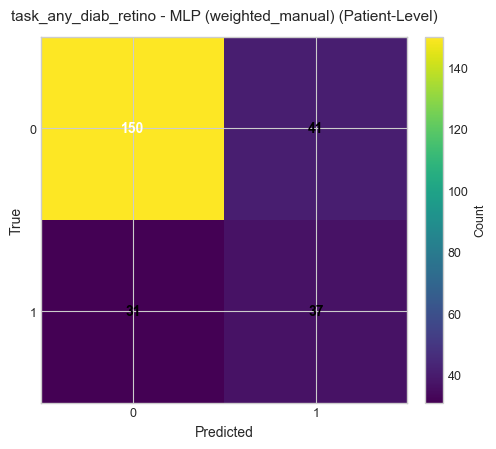

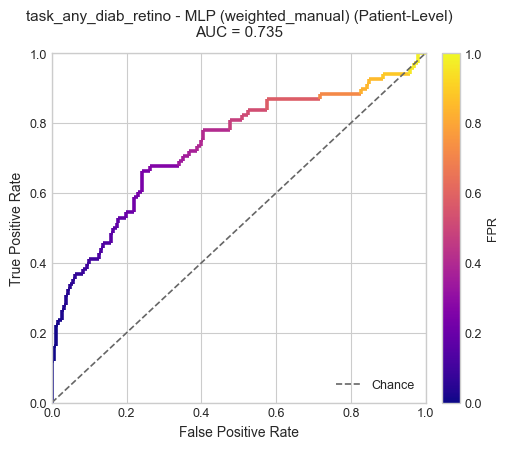


--- Task: task_ref_macular ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.0}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 44 (cosine LR schedule)
  Threshold (sweep): 0.280

  Patient-Level: F1=0.543  Prec=0.641  Rec=0.472  BalAcc=0.702  AUC=0.817  (259 pts)
              precision    recall  f1-score   support

           0      0.873     0.932     0.901       206
           1      0.641     0.472     0.543        53

    accuracy                          0.838       259
   macro avg      0.757     0.702     0.722       259
weighted avg      0.825     0.838     0.828       259



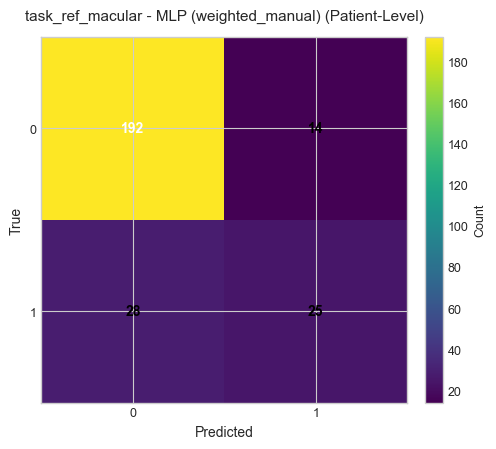

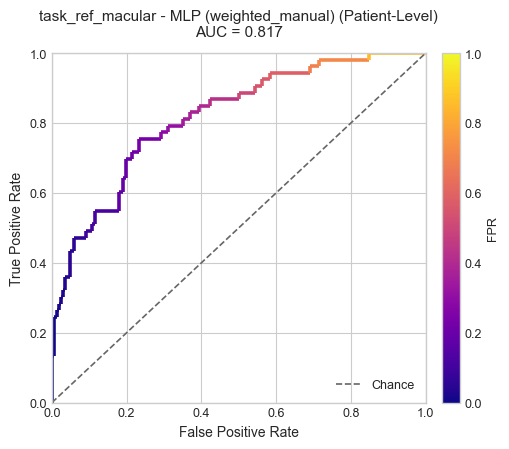


Embedding 2/7: Embeddings_mbrset_dinov3_convnext_base

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 11.0}
  MLP: (256, 128), alpha=0.03, lr=0.0005, schedule=cosine
  Best epoch: 35 (cosine LR schedule)
  Threshold (sweep): 0.711

  Patient-Level: F1=0.432  Prec=0.423  Rec=0.441  BalAcc=0.613  AUC=0.686  (259 pts)
              precision    recall  f1-score   support

           0      0.798     0.785     0.792       191
           1      0.423     0.441     0.432        68

    accuracy                          0.695       259
   macro avg      0.610     0.613     0.612       259
weighted avg      0.699     0.695     0.697       259



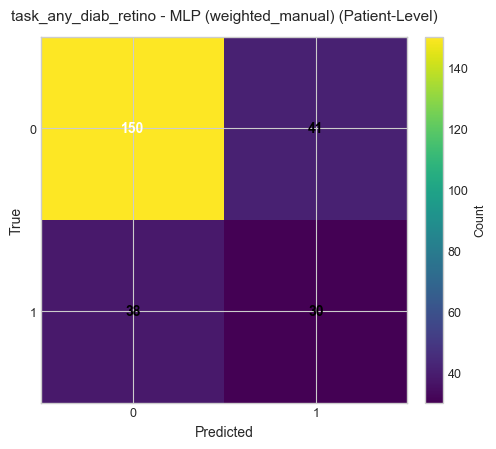

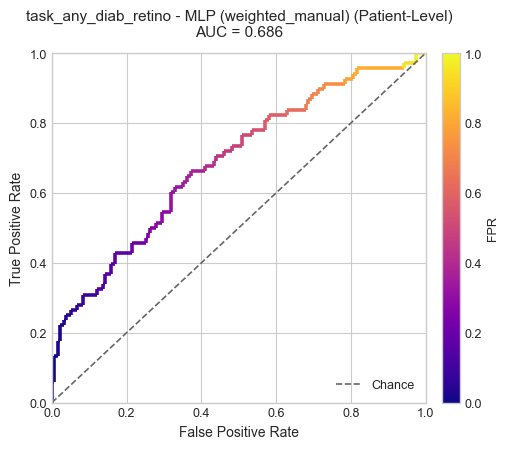


--- Task: task_ref_macular ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 5.5}
  MLP: (256, 128), alpha=0.03, lr=0.0005, schedule=cosine
  Best epoch: 25 (cosine LR schedule)
  Threshold (sweep): 0.657

  Patient-Level: F1=0.382  Prec=0.867  Rec=0.245  BalAcc=0.618  AUC=0.756  (259 pts)
              precision    recall  f1-score   support

           0      0.836     0.990     0.907       206
           1      0.867     0.245     0.382        53

    accuracy                          0.838       259
   macro avg      0.851     0.618     0.645       259
weighted avg      0.842     0.838     0.799       259



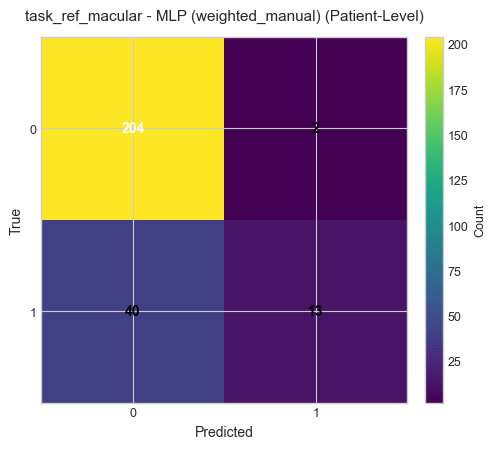

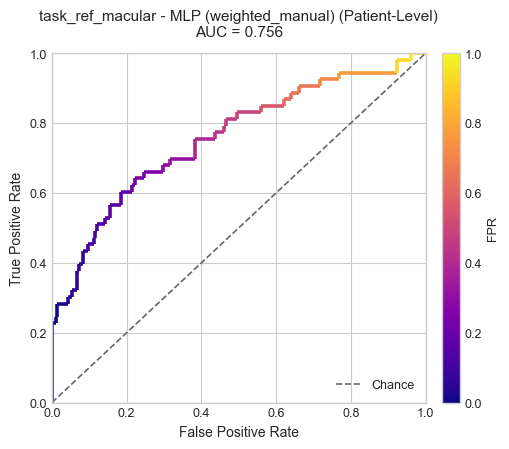


Embedding 3/7: Embeddings_mbrset_dinov3_vitb16

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 5.0}
  MLP: (256, 128), alpha=0.06, lr=0.0005, schedule=cosine
  Best epoch: 41 (cosine LR schedule)
  Threshold (sweep): 0.569

  Patient-Level: F1=0.548  Prec=0.607  Rec=0.500  BalAcc=0.692  AUC=0.746  (259 pts)
              precision    recall  f1-score   support

           0      0.833     0.885     0.858       191
           1      0.607     0.500     0.548        68

    accuracy                          0.784       259
   macro avg      0.720     0.692     0.703       259
weighted avg      0.773     0.784     0.777       259



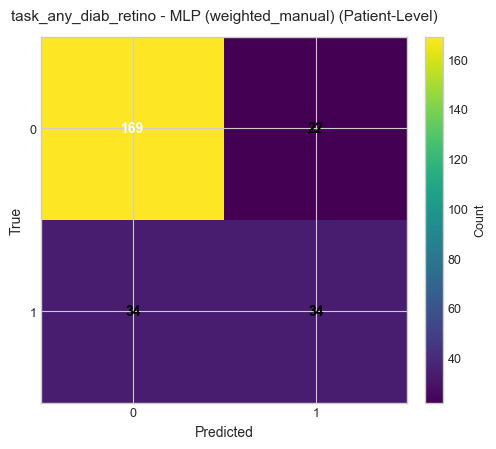

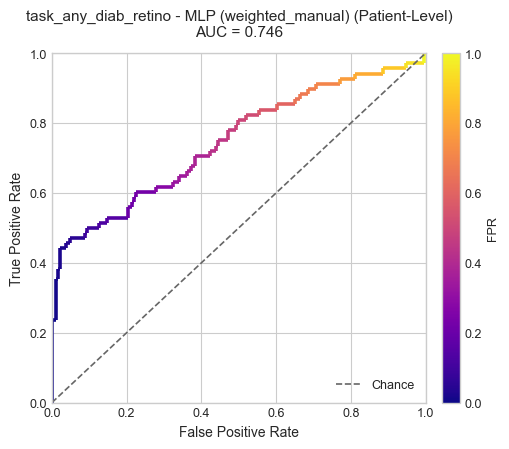


--- Task: task_ref_macular ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 4.0}
  MLP: (256, 128), alpha=0.06, lr=0.0005, schedule=cosine
  Best epoch: 38 (cosine LR schedule)
  Threshold (sweep): 0.475

  Patient-Level: F1=0.598  Prec=0.765  Rec=0.491  BalAcc=0.726  AUC=0.844  (259 pts)
              precision    recall  f1-score   support

           0      0.880     0.961     0.919       206
           1      0.765     0.491     0.598        53

    accuracy                          0.865       259
   macro avg      0.822     0.726     0.758       259
weighted avg      0.856     0.865     0.853       259



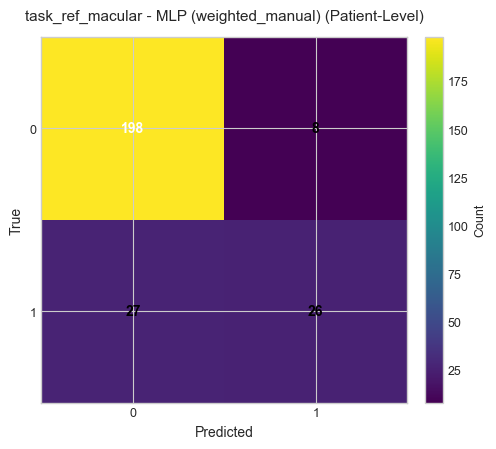

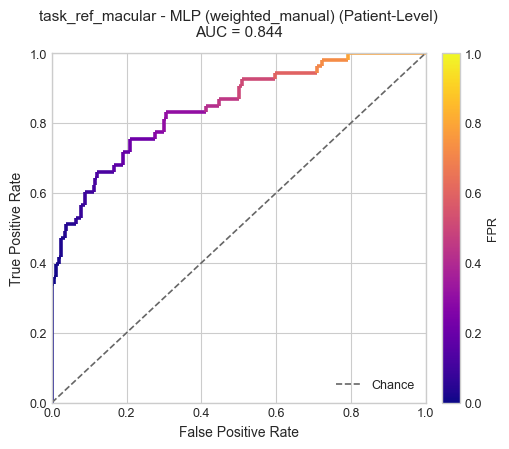


Embedding 4/7: Embeddings_mbrset_RETFound_dinov2_shanghai

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.2}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 38 (cosine LR schedule)
  Threshold (sweep): 0.333

  Patient-Level: F1=0.574  Prec=0.607  Rec=0.544  BalAcc=0.709  AUC=0.791  (259 pts)
              precision    recall  f1-score   support

           0      0.843     0.874     0.859       191
           1      0.607     0.544     0.574        68

    accuracy                          0.788       259
   macro avg      0.725     0.709     0.716       259
weighted avg      0.781     0.788     0.784       259



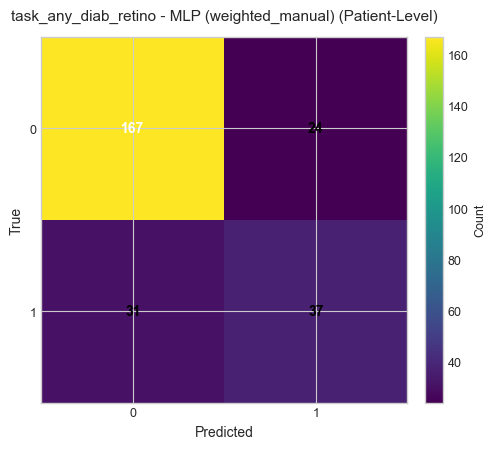

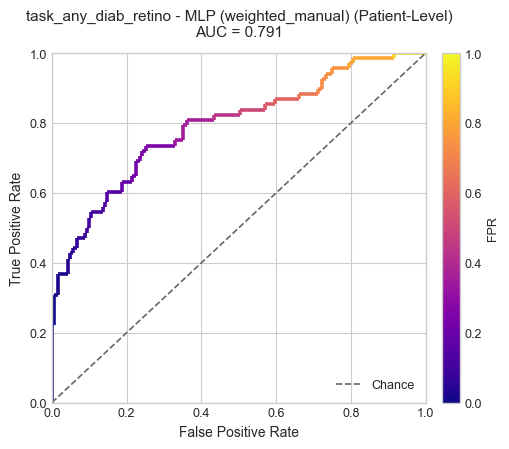


--- Task: task_ref_macular ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 2.0}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 32 (cosine LR schedule)
  Threshold (sweep): 0.456

  Patient-Level: F1=0.615  Prec=0.960  Rec=0.453  BalAcc=0.724  AUC=0.838  (259 pts)
              precision    recall  f1-score   support

           0      0.876     0.995     0.932       206
           1      0.960     0.453     0.615        53

    accuracy                          0.884       259
   macro avg      0.918     0.724     0.774       259
weighted avg      0.893     0.884     0.867       259



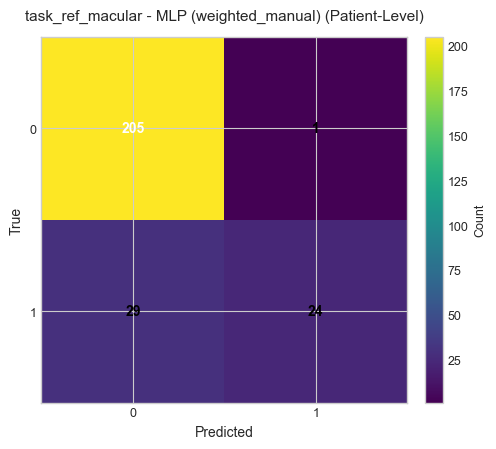

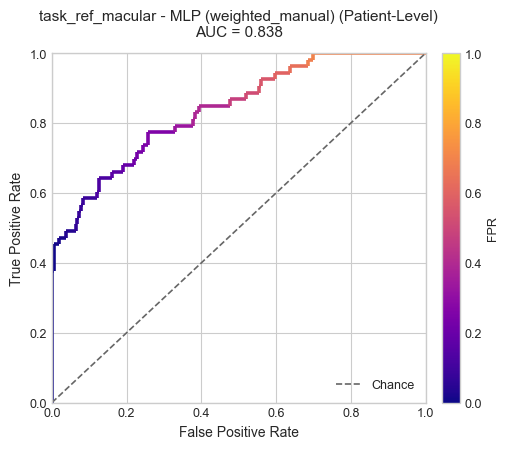


Embedding 5/7: Embeddings_mbrset_RETFound_mae_natureCFP

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.0}
  MLP: (256, 128), alpha=0.03, lr=0.0005, schedule=cosine
  Best epoch: 39 (cosine LR schedule)
  Threshold (sweep): 0.319

  Patient-Level: F1=0.487  Prec=0.569  Rec=0.426  BalAcc=0.656  AUC=0.714  (259 pts)
              precision    recall  f1-score   support

           0      0.812     0.885     0.847       191
           1      0.569     0.426     0.487        68

    accuracy                          0.764       259
   macro avg      0.691     0.656     0.667       259
weighted avg      0.748     0.764     0.753       259



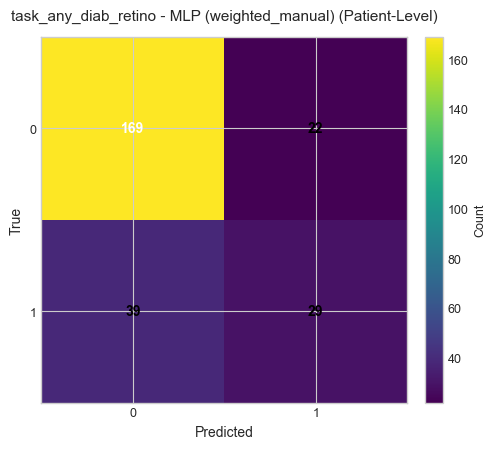

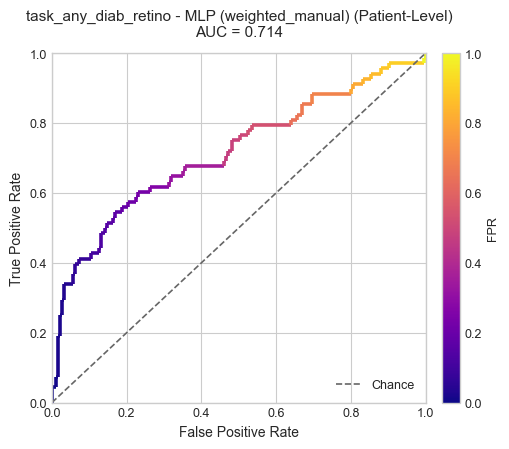


--- Task: task_ref_macular ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.2}
  MLP: (256, 128), alpha=0.03, lr=0.0005, schedule=cosine
  Best epoch: 44 (cosine LR schedule)
  Threshold (sweep): 0.250

  Patient-Level: F1=0.518  Prec=0.492  Rec=0.547  BalAcc=0.701  AUC=0.771  (259 pts)
              precision    recall  f1-score   support

           0      0.880     0.854     0.867       206
           1      0.492     0.547     0.518        53

    accuracy                          0.792       259
   macro avg      0.686     0.701     0.692       259
weighted avg      0.801     0.792     0.796       259



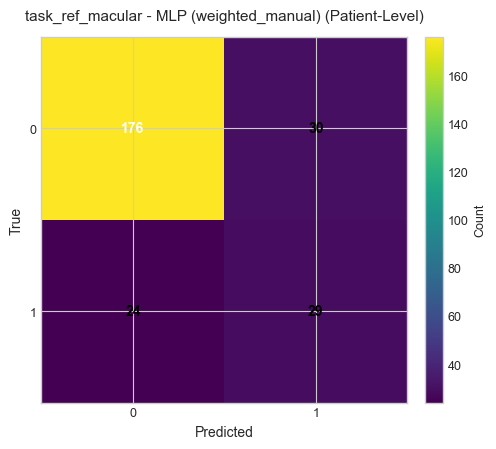

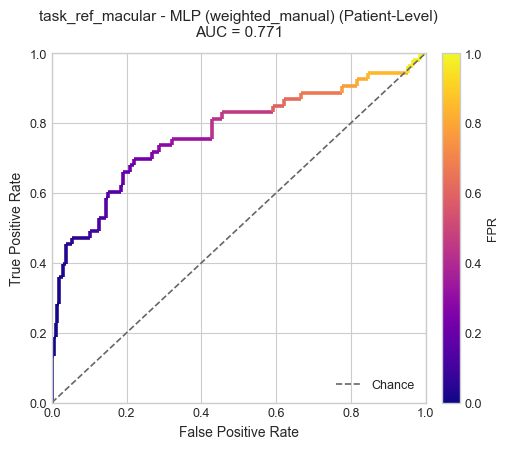


Embedding 6/7: Embeddings_mbrset_RETFound_mae_shanghai

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 7.0}
  MLP: (256, 128), alpha=0.04, lr=0.0005, schedule=cosine
  Best epoch: 33 (cosine LR schedule)
  Threshold (sweep): 0.667

  Patient-Level: F1=0.424  Prec=0.500  Rec=0.368  BalAcc=0.618  AUC=0.677  (259 pts)
              precision    recall  f1-score   support

           0      0.794     0.869     0.830       191
           1      0.500     0.368     0.424        68

    accuracy                          0.737       259
   macro avg      0.647     0.618     0.627       259
weighted avg      0.717     0.737     0.723       259



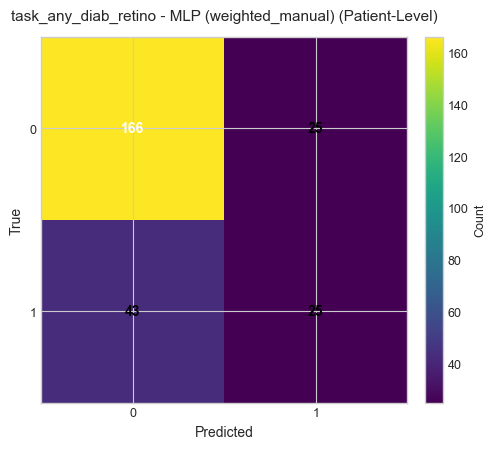

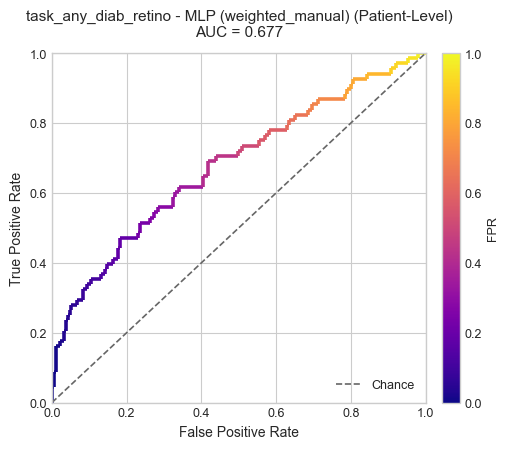


--- Task: task_ref_macular ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 13.0}
  MLP: (256, 128), alpha=0.04, lr=0.0005, schedule=cosine
  Best epoch: 30 (cosine LR schedule)
  Threshold (sweep): 0.706

  Patient-Level: F1=0.452  Prec=0.525  Rec=0.396  BalAcc=0.652  AUC=0.755  (259 pts)
              precision    recall  f1-score   support

           0      0.854     0.908     0.880       206
           1      0.525     0.396     0.452        53

    accuracy                          0.803       259
   macro avg      0.689     0.652     0.666       259
weighted avg      0.787     0.803     0.792       259



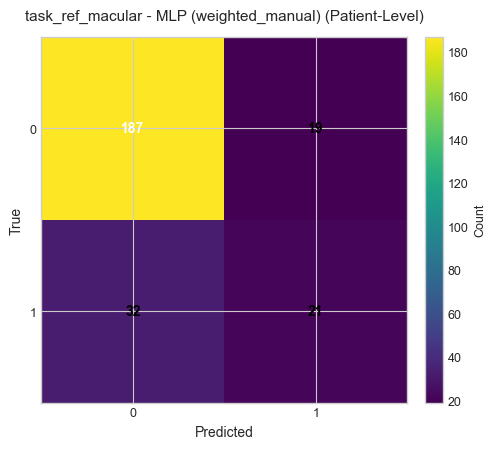

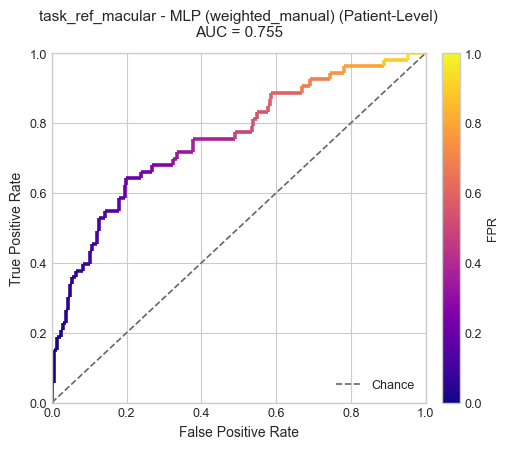


Embedding 7/7: Embeddings_vit_base_mbrset

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 14.0}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 27 (cosine LR schedule)
  Threshold (sweep): 0.760

  Patient-Level: F1=0.400  Prec=0.419  Rec=0.382  BalAcc=0.597  AUC=0.669  (259 pts)
              precision    recall  f1-score   support

           0      0.787     0.812     0.799       191
           1      0.419     0.382     0.400        68

    accuracy                          0.699       259
   macro avg      0.603     0.597     0.599       259
weighted avg      0.690     0.699     0.694       259



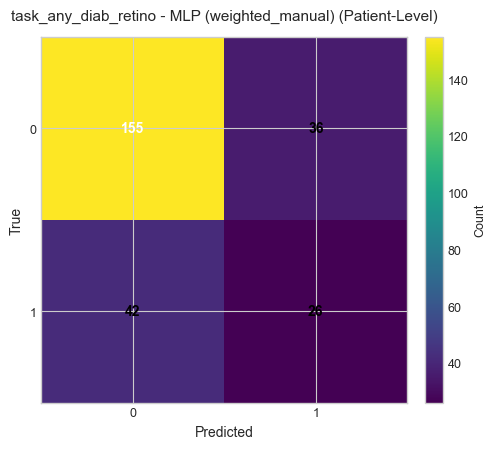

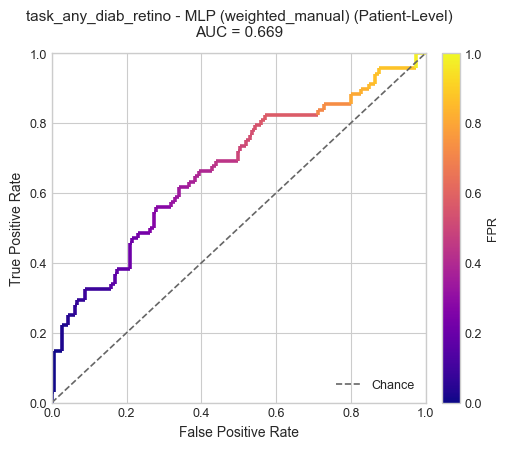


--- Task: task_ref_macular ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 2.8}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 38 (cosine LR schedule)
  Threshold (sweep): 0.392

  Patient-Level: F1=0.515  Prec=0.542  Rec=0.491  BalAcc=0.692  AUC=0.765  (259 pts)
              precision    recall  f1-score   support

           0      0.872     0.893     0.882       206
           1      0.542     0.491     0.515        53

    accuracy                          0.811       259
   macro avg      0.707     0.692     0.699       259
weighted avg      0.804     0.811     0.807       259



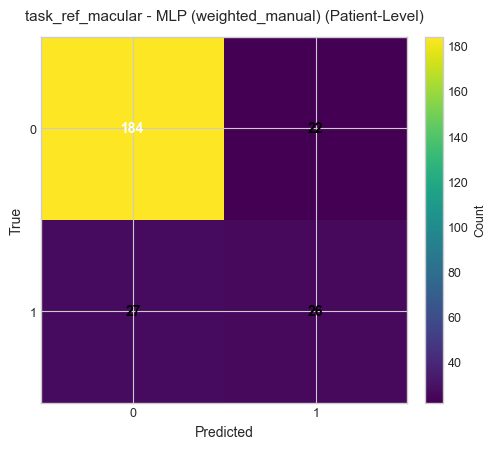

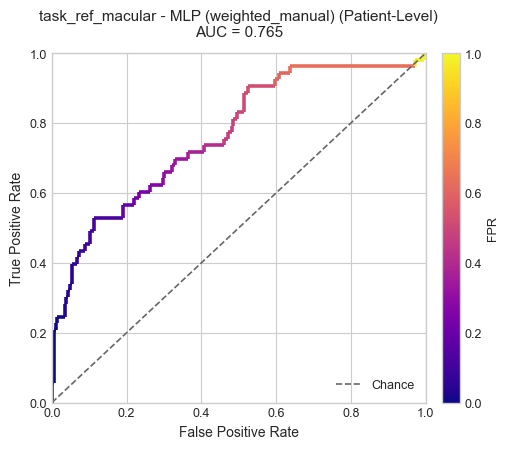


Training and evaluation complete!


In [6]:
# ——— Train on 80% train, evaluate on 20% test (patient-level) ———
all_results = []

# Merge sweep overrides (from Cell 11) with config overrides
_rt_w = globals().get('WEIGHTING_OVERRIDES', {})
_rt_t = globals().get('THRESHOLD_OVERRIDES', {})
_rt_w = _rt_w if isinstance(_rt_w, dict) else {}
_rt_t = _rt_t if isinstance(_rt_t, dict) else {}
WEIGHTING_OVERRIDES = copy.deepcopy(WEIGHTING_OVERRIDES_CONFIG)
THRESHOLD_OVERRIDES = copy.deepcopy(THRESHOLD_OVERRIDES_CONFIG)
for _e, _tc in _rt_w.items():
    WEIGHTING_OVERRIDES.setdefault(_e, {}).update(_tc if isinstance(_tc, dict) else {})
for _e, _tc in _rt_t.items():
    THRESHOLD_OVERRIDES.setdefault(_e, {}).update(_tc if isinstance(_tc, dict) else {})

print(f"Weight overrides: {len(WEIGHTING_OVERRIDES)} embeddings")
print(f"Threshold overrides: {len(THRESHOLD_OVERRIDES)} embeddings")
for en in WEIGHTING_OVERRIDES:
    for tk in WEIGHTING_OVERRIDES[en]:
        w = WEIGHTING_OVERRIDES[en][tk].get('manual', {}).get(1, '?')
        t = THRESHOLD_OVERRIDES.get(en, {}).get(tk, 'none')
        print(f"  {en} / {tk}: weight={w}, threshold={t}")

def get_effective_weight_cfg(emb_stem, task):
    base = (WEIGHTING_CONFIG or {}).get('binary', {})
    emb_over = (WEIGHTING_OVERRIDES or {}).get(emb_stem, {})
    task_over = emb_over.get(task, {}) if isinstance(emb_over, dict) else {}
    cfg = dict(base)
    if USE_EMBEDDING_TASK_WEIGHT_OVERRIDES and isinstance(task_over, dict) and task_over:
        cfg.update(task_over)
    cfg.setdefault('mode', 'manual')
    cfg.setdefault('manual', {0: 1.0, 1: 1.0})
    cfg.setdefault('damping_gamma', 1.0)
    return cfg

EVAL_TARGET_PATTERNS = ["RETFound", "dinov3", "vit_base", "convnextv2"]
eval_embedding_files = [
    emb for emb in embedding_files
    if any(p.lower() in emb.stem.lower() for p in EVAL_TARGET_PATTERNS)
]
print(f"\nEvaluating {len(eval_embedding_files)} embeddings:")
for emb in eval_embedding_files:
    print(f"  - {emb.stem}")

for emb_idx, emb_path in enumerate(eval_embedding_files):
    print(f"\n{'='*80}")
    print(f"Embedding {emb_idx+1}/{len(eval_embedding_files)}: {emb_path.stem}")
    print(f"{'='*80}")

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )

    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].copy()
    test_df = all_df[all_df['patient_id'].isin(test_patient_ids)].copy()

    for task in BINARY_TASKS:
        if task not in ds.df.columns:
            continue

        display_task = BINARY_TASK_MAP.get(task, task)
        print(f"\n--- Task: {display_task} ---")

        train_work = train_df.dropna(subset=[task]).copy()
        test_work = test_df.dropna(subset=[task]).copy()

        if train_work.empty or test_work.empty:
            print(f"  Skipping: insufficient data")
            continue

        X_train = train_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_train = train_work[task].astype(int).to_numpy()
        X_test = test_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_test = test_work[task].astype(int).to_numpy()

        classes, counts = np.unique(y_train, return_counts=True)
        print(f"  Train: {len(X_train)} imgs, {train_work['patient_id'].nunique()} pts")
        print(f"  Test:  {len(X_test)} imgs, {test_work['patient_id'].nunique()} pts")
        print(f"  Class dist (train): {dict(zip(classes.astype(int), counts))}")

        # PCA
        if USE_PCA:
            pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)

        # Scale
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Per-embedding weight from sweep (or fallback to balanced)
        weight_cfg = get_effective_weight_cfg(emb_path.stem, task)
        weight_mode = weight_cfg.get("mode", "balanced")
        has_override = task in (WEIGHTING_OVERRIDES.get(emb_path.stem, {}) or {})

        class_weight_mapping = compute_class_weight_mapping(
            y_train,
            mode=weight_mode,
            manual_class_weight=weight_cfg.get("manual"),
            damping_gamma=weight_cfg.get("damping_gamma", 1.0),
        )
        sample_weights = compute_sample_weights(y_train, class_weight_mapping, normalize=True)
        weight_name = f"weighted_{weight_mode}"
        print(f"  Weights: {'SWEEP' if has_override else 'base'}, mode={weight_mode}, map={class_weight_mapping}")

        # ——— Train MLP with cosine LR schedule ———
        mlp_cfg, _ = resolve_config(emb_path.stem)
        _lr_sched = mlp_cfg.get("lr_schedule", "constant")
        print(f"  MLP: {mlp_cfg['hidden_layer_sizes']}, alpha={mlp_cfg['alpha']}, "
              f"lr={mlp_cfg['learning_rate_init']}, schedule={_lr_sched}")

        # Internal 85/15 val split for early stopping
        from sklearn.model_selection import train_test_split as _eval_split
        _X_tr, _X_va, _y_tr, _y_va, _idx_tr, _idx_va = _eval_split(
            X_train_scaled, y_train, np.arange(len(y_train)),
            test_size=0.15, random_state=RANDOM_SEED, stratify=y_train,
        )
        _sw_tr = compute_sample_weights(_y_tr, class_weight_mapping, normalize=True)
        _sw_va = compute_sample_weights(_y_va, class_weight_mapping, normalize=True)

        best_model, _best_ep, _, _ = train_mlp_with_schedule(
            _X_tr, _y_tr, _X_va, _y_va, mlp_cfg,
            sample_weight_train=_sw_tr, sample_weight_val=_sw_va,
            random_seed=RANDOM_SEED,
        )
        print(f"  Best epoch: {_best_ep} ({_lr_sched} LR schedule)")

        # ——— THRESHOLD from sweep or compute on inner val ———
        thresh_override = (THRESHOLD_OVERRIDES.get(emb_path.stem, {}) or {}).get(task, None)

        if thresh_override is not None:
            opt_thresh = float(thresh_override)
            thresh_src = "sweep"
        else:
            # No sweep threshold — use our val split for threshold finding
            _val_proba = best_model.predict_proba(_X_va)[:, 1]
            _val_pids = train_work.iloc[_idx_va]["patient_id"].values
            _val_agg = pd.DataFrame({
                "patient_id": _val_pids, "y_true": _y_va, "y_proba": _val_proba
            }).groupby("patient_id").agg(y_true=("y_true", "max"), y_proba=("y_proba", "mean"))
            opt_thresh = find_optimal_threshold(
                _val_agg["y_true"].to_numpy(), _val_agg["y_proba"].to_numpy(),
                method=THRESHOLD_METHOD, grid_size=THRESHOLD_GRID_SIZE
            )
            thresh_src = f"{THRESHOLD_METHOD}_inner_val"

        print(f"  Threshold ({thresh_src}): {opt_thresh:.3f}")

        # ——— TEST: patient-level evaluation ———
        y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]

        test_agg = pd.DataFrame({
            "patient_id": test_work["patient_id"].values,
            "y_true": y_test,
            "y_proba": y_proba_test,
        }).groupby("patient_id").agg(
            y_true=("y_true", "max"),
            y_proba=("y_proba", "mean"),
        ).reset_index()
        test_agg["y_pred"] = (test_agg["y_proba"] >= opt_thresh).astype(int)

        y_true_pt = test_agg["y_true"].to_numpy()
        y_pred_pt = test_agg["y_pred"].to_numpy()
        y_proba_pt = test_agg["y_proba"].to_numpy()

        # Metrics
        accuracy = (y_true_pt == y_pred_pt).mean()
        f1 = f1_score(y_true_pt, y_pred_pt, zero_division=0)
        precision = precision_score(y_true_pt, y_pred_pt, zero_division=0)
        recall = recall_score(y_true_pt, y_pred_pt, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_true_pt, y_pred_pt)
        fpr, tpr, _ = roc_curve(y_true_pt, y_proba_pt)
        auc = roc_auc_score(y_true_pt, y_proba_pt)

        print(f"\n  Patient-Level: F1={f1:.3f}  Prec={precision:.3f}  Rec={recall:.3f}  "
              f"BalAcc={balanced_acc:.3f}  AUC={auc:.3f}  ({len(test_agg)} pts)")

        report_text = classification_report(y_true_pt, y_pred_pt, digits=3)
        print(report_text)

        cm = confusion_matrix(y_true_pt, y_pred_pt)

        # Save outputs
        out_dir = RESULTS_DIR / f"{emb_idx:02d}_{emb_path.stem}" / display_task / "mlp"
        out_dir.mkdir(parents=True, exist_ok=True)

        (out_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")
        pd.DataFrame(cm).to_csv(out_dir / "confusion_matrix.csv", index=False)
        plot_confusion_matrix(
            cm,
            title=f"{display_task} - MLP ({weight_name}) (Patient-Level)",
            save_path=out_dir / "confusion_matrix.png" if SAVE_PLOTS else None,
            show=SHOW_PLOTS,
        )

        pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(out_dir / "roc_curve.csv", index=False)
        plot_roc_curve(
            fpr, tpr, auc,
            title=f"{display_task} - MLP ({weight_name}) (Patient-Level)",
            save_path=out_dir / "roc_curve.png" if SAVE_PLOTS else None,
            show=SHOW_PLOTS,
        )

        test_agg.to_csv(out_dir / "patient_predictions.csv", index=False)

        all_results.append({
            "embedding_idx": emb_idx,
            "embedding": emb_path.stem,
            "task": display_task,
            "model": "mlp",
            "weighting": weight_name,
            "threshold": float(opt_thresh),
            "threshold_src": thresh_src,
            "n_patients": len(test_agg),
            "accuracy": float(accuracy),
            "balanced_accuracy": float(balanced_acc),
            "f1_score": float(f1),
            "precision": float(precision),
            "recall": float(recall),
            "auc": float(auc),
            "output_dir": str(out_dir),
        })

print(f"\n{'='*80}")
print("Training and evaluation complete!")
print(f"{'='*80}")

## 6. Summary Table

In [7]:
# Create summary DataFrame from the main train/eval cell results
try:
    if not all_results:
        raise ValueError("all_results is empty. Run the Train/Evaluate cell (Cell 13) first.")
    summary_df = pd.DataFrame(all_results)
except NameError:
    raise ValueError("all_results not found. Run the Train/Evaluate cell (Cell 13) first.")

# Sort by task and F1 score
summary_df = summary_df.sort_values(["task", "f1_score"], ascending=[True, False]).reset_index(drop=True)

# Save summary
summary_path = RESULTS_DIR / "summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary to: {summary_path}")
print(f"Total results: {len(summary_df)} rows")
print(f"  - Embeddings: {summary_df['embedding'].nunique()}")
print(f"  - Tasks: {summary_df['task'].nunique()}")
print(f"  - Models: {summary_df['model'].nunique()}")

# Display comprehensive summary
print("\n" + "="*100)
print("SUMMARY OF RESULTS (Patient-Level)")
print("="*100)

display_cols = ["embedding", "task", "weighting", "n_patients", "accuracy", "balanced_accuracy", 
                "f1_score", "precision", "recall", "auc"]
if USE_BAYESIAN_SEARCH and "best_cv_score" in summary_df.columns:
    display_cols.insert(-3, "best_cv_score")

print(summary_df[display_cols].to_string(index=False))

# Show top performers by task
print("\n" + "="*100)
print("TOP PERFORMERS BY TASK")
print("="*100)
for task in summary_df['task'].unique():
    task_data = summary_df[summary_df['task'] == task].nlargest(3, 'f1_score')
    print(f"\n{task}:")
    print(task_data[["embedding", "f1_score", "balanced_accuracy", "auc"]].to_string(index=False))

summary_df

Saved summary to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval\summary.csv
Total results: 14 rows
  - Embeddings: 7
  - Tasks: 2
  - Models: 1

SUMMARY OF RESULTS (Patient-Level)
                                 embedding                 task       weighting  n_patients  accuracy  balanced_accuracy  f1_score  precision   recall      auc
Embeddings_mbrset_RETFound_dinov2_shanghai task_any_diab_retino weighted_manual         259  0.787645           0.709232  0.573643   0.606557 0.544118 0.791500
           Embeddings_mbrset_dinov3_vitb16 task_any_diab_retino weighted_manual         259  0.783784           0.692408  0.548387   0.607143 0.500000 0.745996
         Embeddings_convnextv2_base_mbrset task_any_diab_retino weighted_manual         259  0.722008           0.664729  0.506849   0.474359 0.544118 0.734678
  Embeddings_mbrset_RETFound_mae_natureCFP task_any_diab_retino weighted_manual         259  0.764479  

,embedding_idx,embedding,task,model,weighting,threshold,threshold_src,n_patients,accuracy,balanced_accuracy,f1_score,precision,recall,auc,output_dir
0,3,Embeddings_mbrset_RETFound_dinov2_shanghai,task_any_diab_retino,mlp,weighted_manual,0.3334,sweep,259,0.787645,0.709232,0.573643,0.606557,0.544118,0.791500,c:\Users\Julian\OneDrive\Desktop\testing-retin...
1,2,Embeddings_mbrset_dinov3_vitb16,task_any_diab_retino,mlp,weighted_manual,0.5686,sweep,259,0.783784,0.692408,0.548387,0.607143,0.500000,0.745996,c:\Users\Julian\OneDrive\Desktop\testing-retin...
2,0,Embeddings_convnextv2_base_mbrset,task_any_diab_retino,mlp,weighted_manual,0.2942,sweep,259,0.722008,0.664729,0.506849,0.474359,0.544118,0.734678,c:\Users\Julian\OneDrive\Desktop\testing-retin...
3,4,Embeddings_mbrset_RETFound_mae_natureCFP,task_any_diab_retino,mlp,weighted_manual,0.3187,sweep,259,0.764479,0.655644,0.487395,0.568627,0.426471,0.714352,c:\Users\Julian\OneDrive\Desktop\testing-retin...
4,1,Embeddings_mbrset_dinov3_convnext_base,task_any_diab_retino,mlp,weighted_manual,0.7107,sweep,259,0.694981,0.613258,0.431655,0.422535,0.441176,0.685864,c:\Users\Julian\OneDrive\Desktop\testing-retin...
5,5,Embeddings_mbrset_RETFound_mae_shanghai,task_any_diab_retino,mlp,weighted_manual,0.6666,sweep,259,0.737452,0.618379,0.423729,0.500000,0.367647,0.677241,c:\Users\Julian\OneDrive\Desktop\testing-retin...
6,6,Embeddings_vit_base_mbrset,task_any_diab_retino,mlp,weighted_manual,0.7597,sweep,259,0.698842,0.596936,0.400000,0.419355,0.382353,0.669464,c:\Users\Julian\OneDrive\Desktop\testing-retin...
7,3,Embeddings_mbrset_RETFound_dinov2_shanghai,task_ref_macular,mlp,weighted_manual,0.4559,sweep,259,0.884170,0.723988,0.615385,0.960000,0.452830,0.838157,c:\Users\Julian\OneDrive\Desktop\testing-retin...
8,2,Embeddings_mbrset_dinov3_vitb16,task_ref_macular,mlp,weighted_manual,0.4755,sweep,259,0.864865,0.725866,0.597701,0.764706,0.490566,0.844019,c:\Users\Julian\OneDrive\Desktop\testing-retin...
9,0,Embeddings_convnextv2_base_mbrset,task_ref_macular,mlp,weighted_manual,0.2795,sweep,259,0.837838,0.701868,0.543478,0.641026,0.471698,0.816999,c:\Users\Julian\OneDrive\Desktop\testing-retin...


## 7. Training Dynamics Analysis

Generate training curves showing train vs validation loss to detect overfitting/underfitting.
- **MLP**: epochs (full passes through training data)

This uses an **internal validation split** from the training set (not the test set) to track generalization during training.

Running training dynamics analysis (all embeddings, sweep weights)...
Embeddings: 7
  - Embeddings_convnextv2_base_mbrset
  - Embeddings_mbrset_dinov3_convnext_base
  - Embeddings_mbrset_dinov3_vitb16
  - Embeddings_mbrset_RETFound_dinov2_shanghai
  - Embeddings_mbrset_RETFound_mae_natureCFP
  - Embeddings_mbrset_RETFound_mae_shanghai
  - Embeddings_vit_base_mbrset

Embedding 1/7: Embeddings_convnextv2_base_mbrset

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.2}
  MLP: hidden=(256, 128), alpha=0.05, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 36/86, Train loss: 0.1818, Val loss: 0.4699, Gap: -0.2880, ValDiv: +0.0693 → GOOD FIT


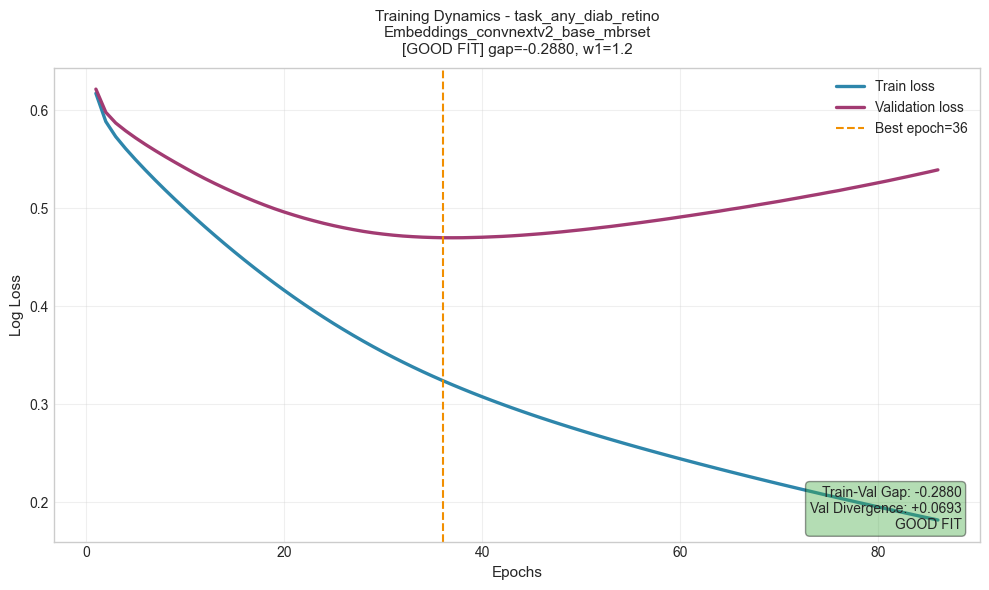


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.0}
  MLP: hidden=(256, 128), alpha=0.05, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 47/97, Train loss: 0.0884, Val loss: 0.3290, Gap: -0.2405, ValDiv: +0.0566 → GOOD FIT


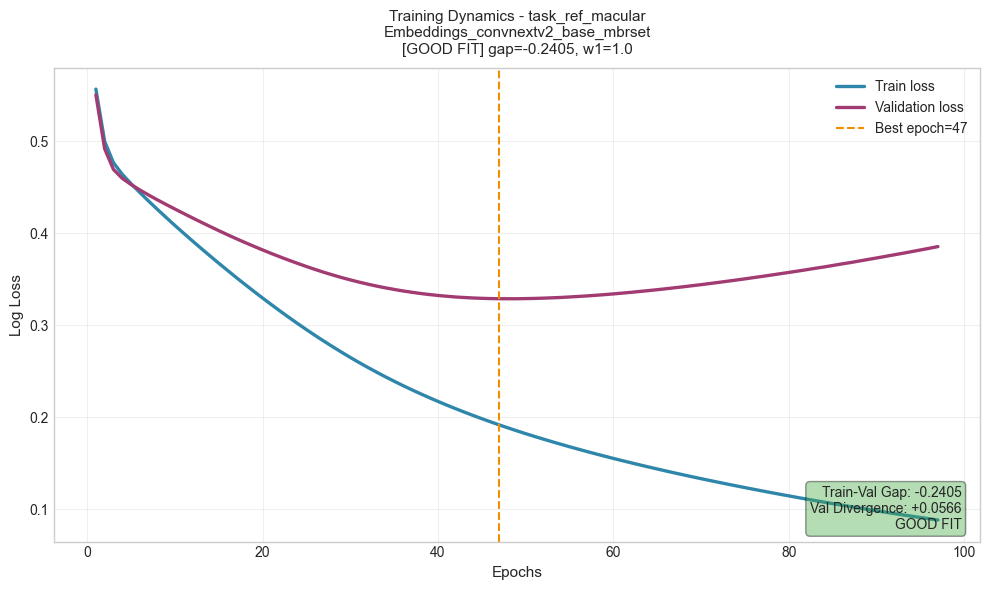


Embedding 2/7: Embeddings_mbrset_dinov3_convnext_base

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 11.0}
  MLP: hidden=(256, 128), alpha=0.03, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 31/81, Train loss: 0.2335, Val loss: 0.4768, Gap: -0.2433, ValDiv: +0.1314 → GOOD FIT


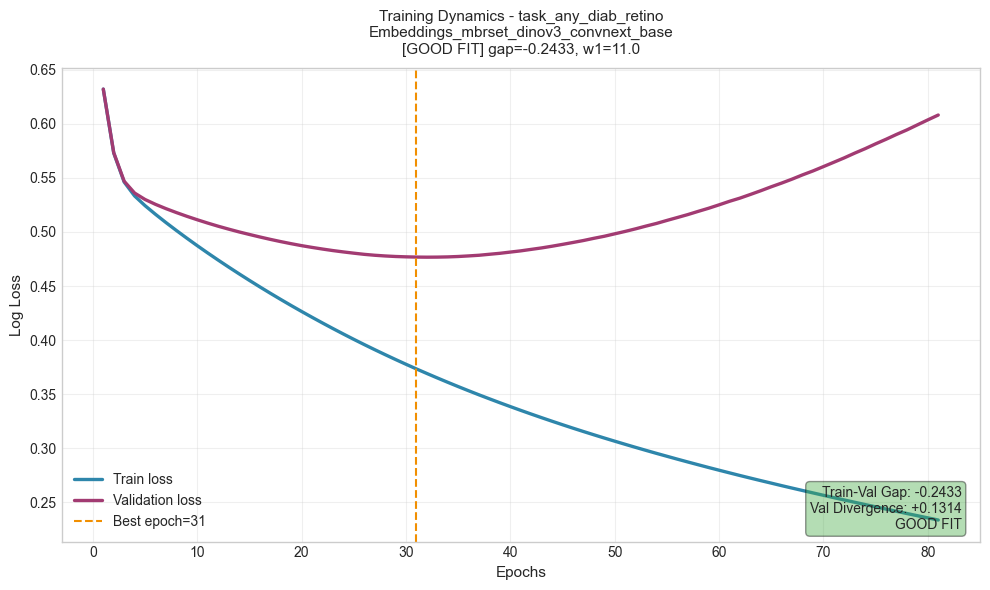


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 5.5}
  MLP: hidden=(256, 128), alpha=0.03, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 26/76, Train loss: 0.2196, Val loss: 0.5906, Gap: -0.3710, ValDiv: +0.2032 → GOOD FIT


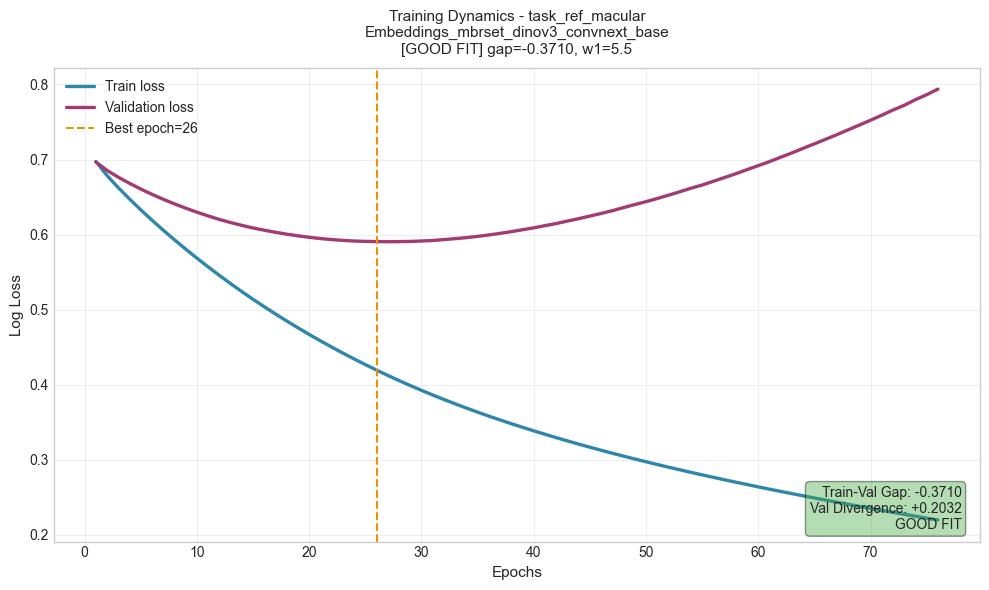


Embedding 3/7: Embeddings_mbrset_dinov3_vitb16

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 5.0}
  MLP: hidden=(256, 128), alpha=0.06, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 43/93, Train loss: 0.1936, Val loss: 0.5421, Gap: -0.3485, ValDiv: +0.1072 → GOOD FIT


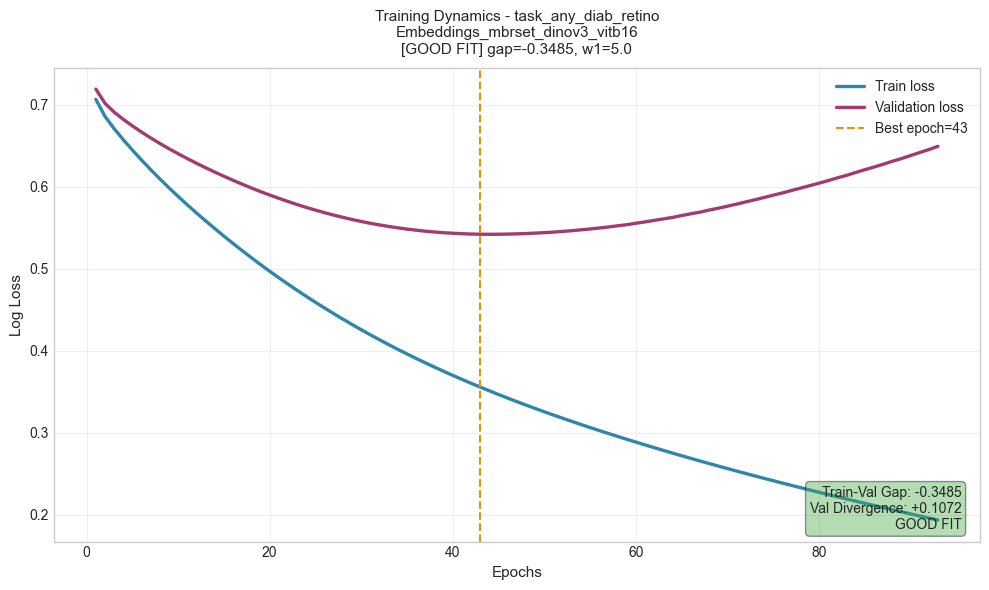


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 4.0}
  MLP: hidden=(256, 128), alpha=0.06, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 40/90, Train loss: 0.1393, Val loss: 0.5259, Gap: -0.3865, ValDiv: +0.1355 → GOOD FIT


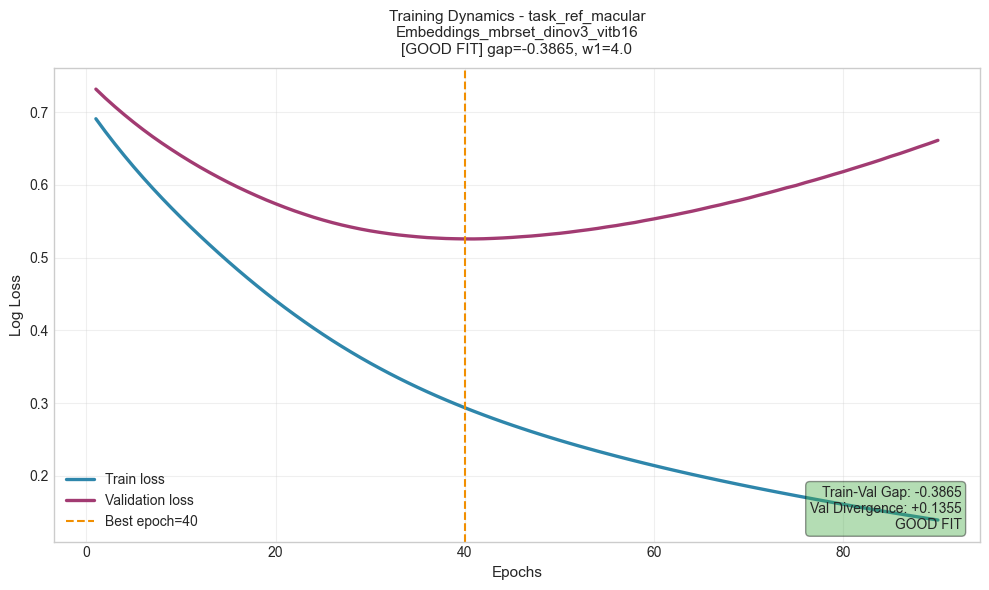


Embedding 4/7: Embeddings_mbrset_RETFound_dinov2_shanghai

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.2}
  MLP: hidden=(256, 128), alpha=0.05, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 36/86, Train loss: 0.1877, Val loss: 0.4592, Gap: -0.2715, ValDiv: +0.0647 → GOOD FIT


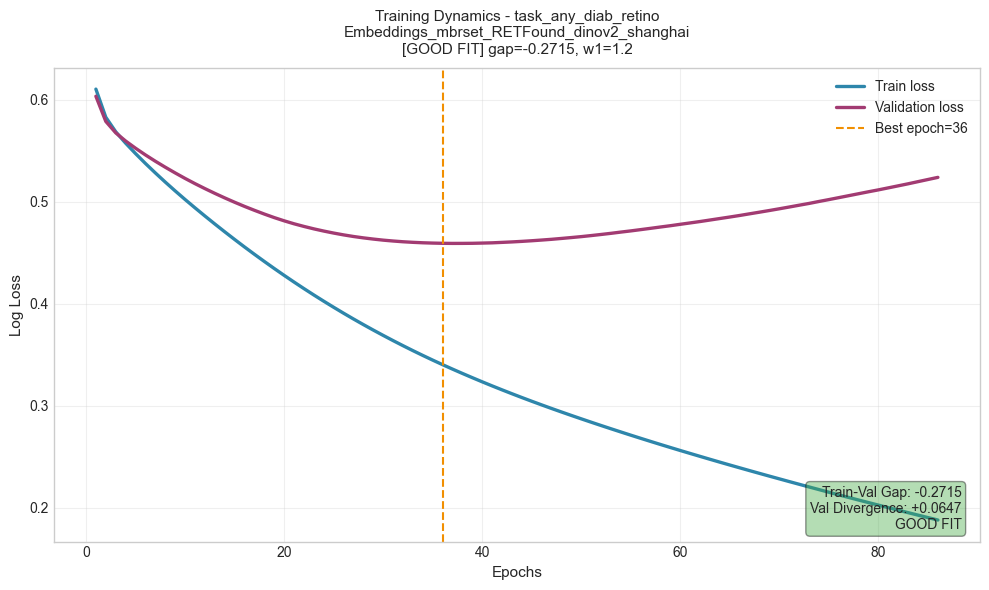


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 2.0}
  MLP: hidden=(256, 128), alpha=0.05, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 35/85, Train loss: 0.1393, Val loss: 0.4514, Gap: -0.3121, ValDiv: +0.1424 → GOOD FIT


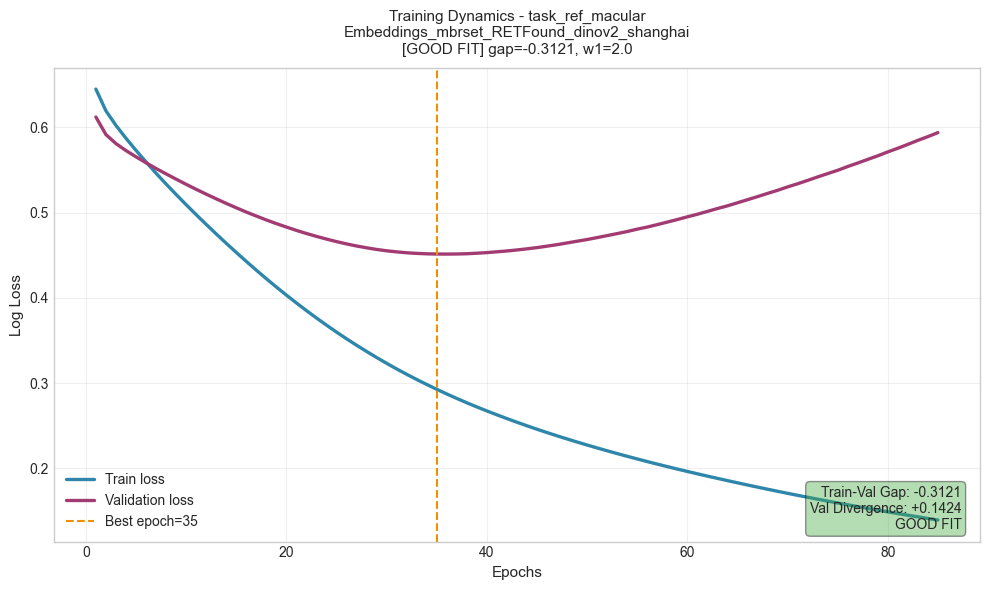


Embedding 5/7: Embeddings_mbrset_RETFound_mae_natureCFP

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.0}
  MLP: hidden=(256, 128), alpha=0.03, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 45/95, Train loss: 0.1836, Val loss: 0.4651, Gap: -0.2815, ValDiv: +0.0451 → GOOD FIT


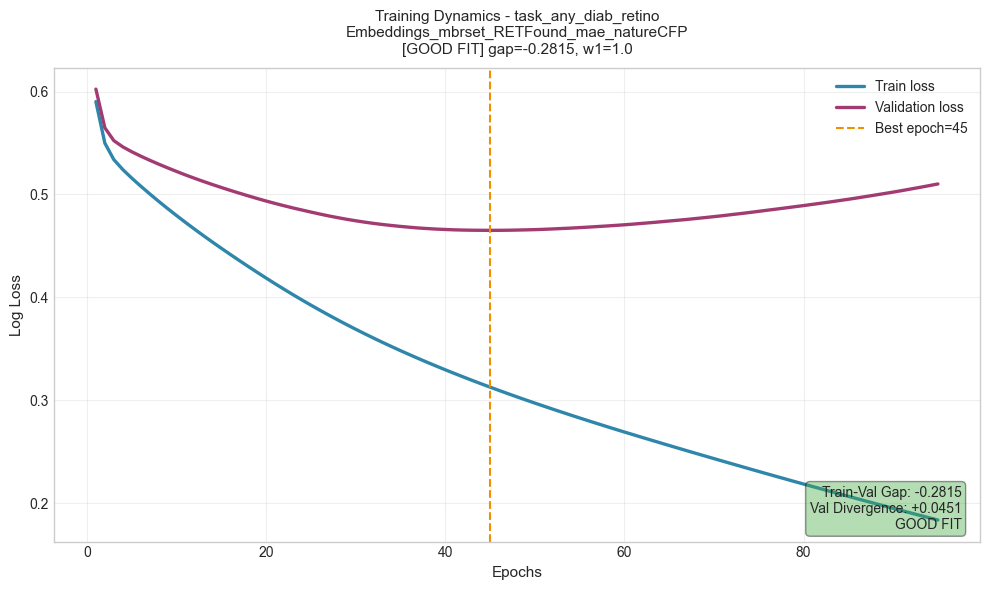


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.2}
  MLP: hidden=(256, 128), alpha=0.03, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 41/91, Train loss: 0.1520, Val loss: 0.4152, Gap: -0.2632, ValDiv: +0.0498 → GOOD FIT


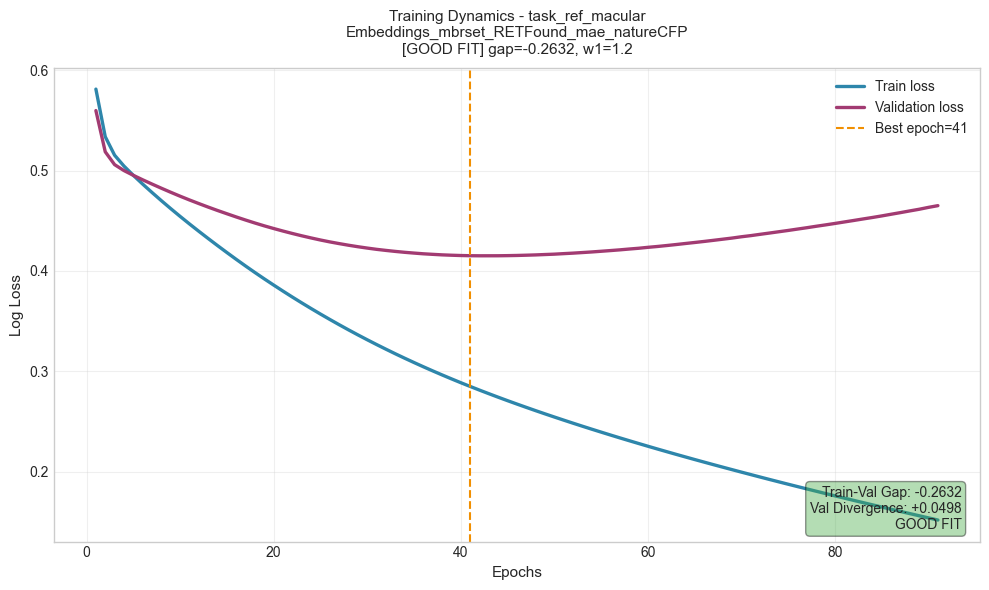


Embedding 6/7: Embeddings_mbrset_RETFound_mae_shanghai

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 7.0}
  MLP: hidden=(256, 128), alpha=0.04, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 35/85, Train loss: 0.2210, Val loss: 0.5314, Gap: -0.3105, ValDiv: +0.1277 → GOOD FIT


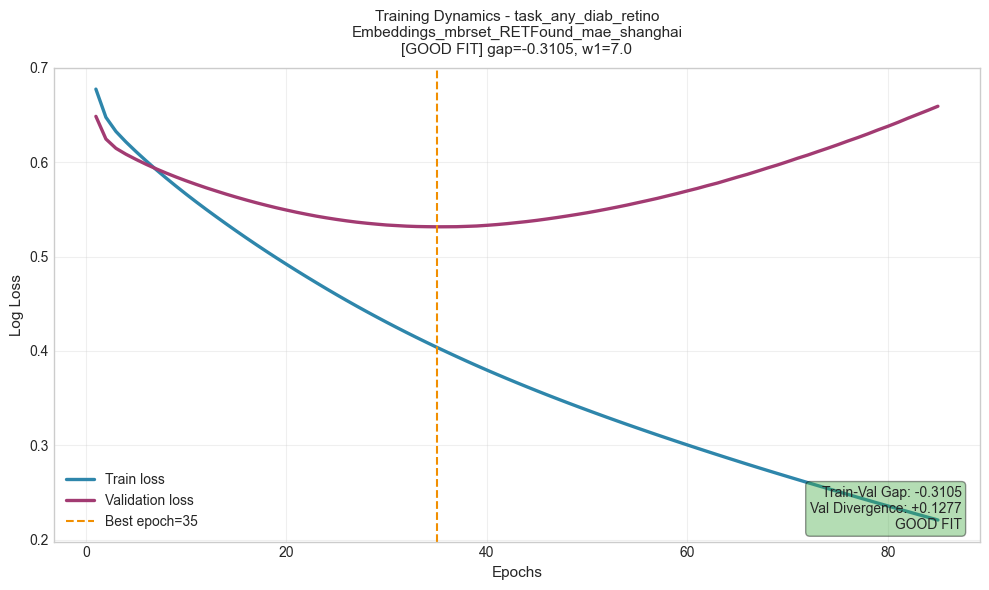


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 13.0}
  MLP: hidden=(256, 128), alpha=0.04, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 32/82, Train loss: 0.1768, Val loss: 0.5044, Gap: -0.3276, ValDiv: +0.1687 → GOOD FIT


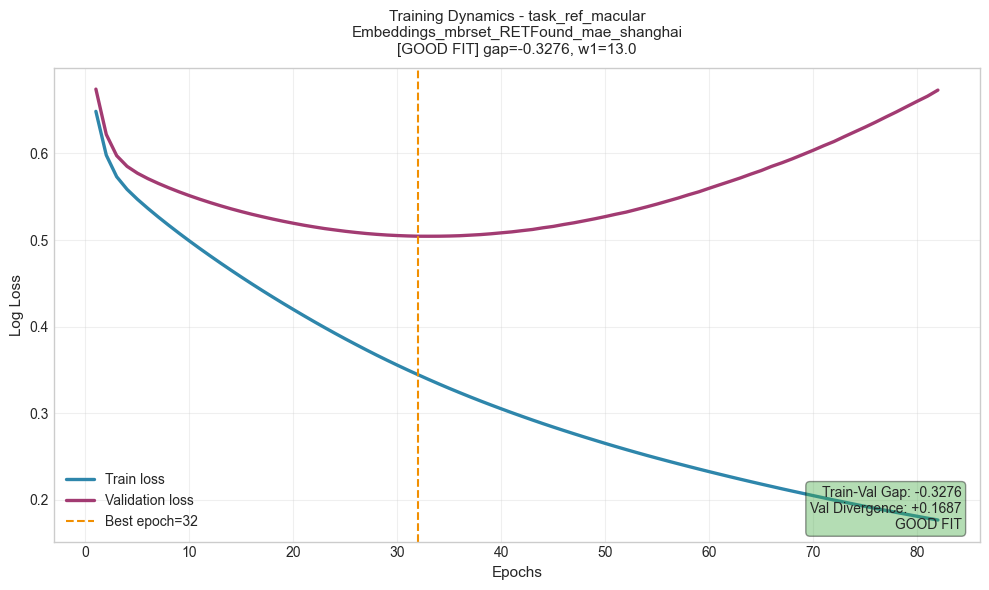


Embedding 7/7: Embeddings_vit_base_mbrset

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 14.0}
  MLP: hidden=(256, 128), alpha=0.05, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 28/78, Train loss: 0.2053, Val loss: 0.4523, Gap: -0.2471, ValDiv: +0.1351 → GOOD FIT


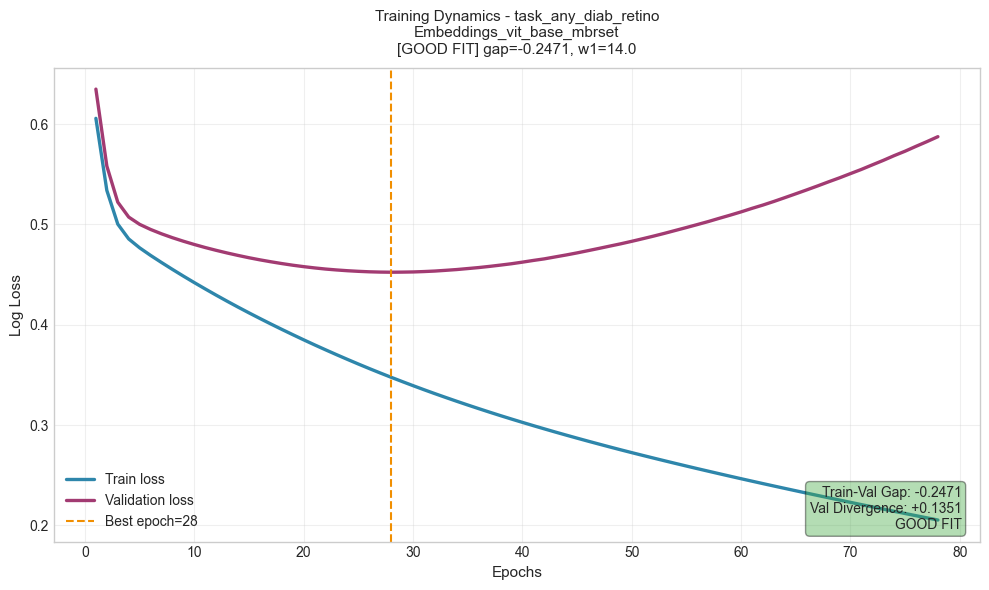


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 2.8}
  MLP: hidden=(256, 128), alpha=0.05, lr=0.0005, schedule=cosine, patience=50, warmup=20
  Best epoch: 41/91, Train loss: 0.1876, Val loss: 0.5693, Gap: -0.3817, ValDiv: +0.0760 → GOOD FIT


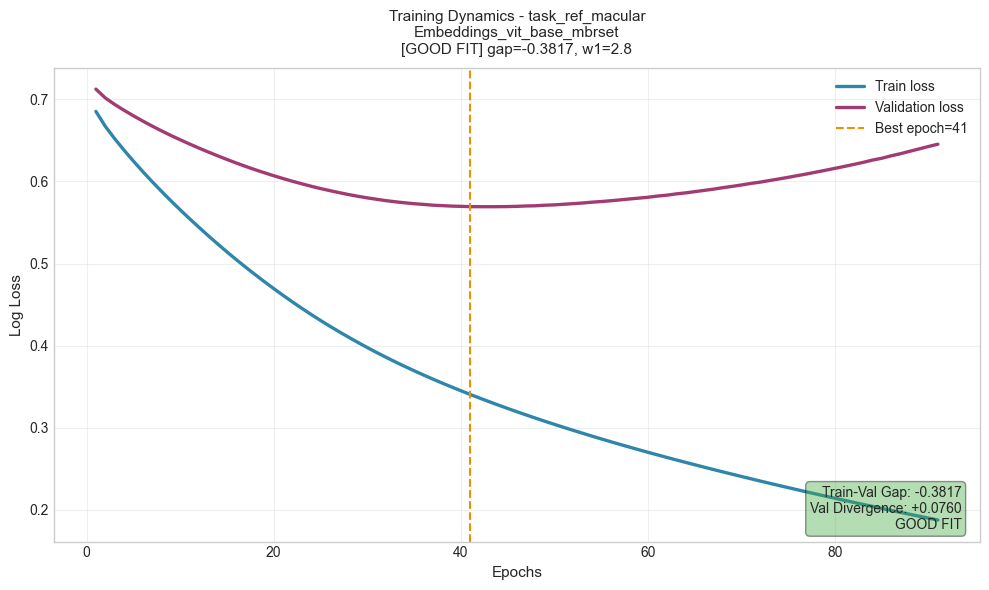


TRAINING DYNAMICS SUMMARY
                                 embedding                 task weight_src  pos_weight  best_epoch  stop_epoch  train_loss  val_loss  train_val_gap  val_divergence diagnosis
         Embeddings_convnextv2_base_mbrset task_any_diab_retino      SWEEP         1.2          36          86      0.1818    0.4699        -0.2880          0.0693  GOOD FIT
         Embeddings_convnextv2_base_mbrset     task_ref_macular      SWEEP         1.0          47          97      0.0884    0.3290        -0.2405          0.0566  GOOD FIT
    Embeddings_mbrset_dinov3_convnext_base task_any_diab_retino      SWEEP        11.0          31          81      0.2335    0.4768        -0.2433          0.1314  GOOD FIT
    Embeddings_mbrset_dinov3_convnext_base     task_ref_macular      SWEEP         5.5          26          76      0.2196    0.5906        -0.3710          0.2032  GOOD FIT
           Embeddings_mbrset_dinov3_vitb16 task_any_diab_retino      SWEEP         5.0          43     

In [8]:
# Training dynamics: ALL embeddings × ALL tasks with sweep weights
import copy

DYNAMICS_DIR = RESULTS_DIR / "training_dynamics"
DYNAMICS_DIR.mkdir(parents=True, exist_ok=True)

print("Running training dynamics analysis (all embeddings, sweep weights)...")

# ——— Use same sweep overrides as Cell 13 ———
_rt_w = globals().get('WEIGHTING_OVERRIDES', {})
_rt_t = globals().get('THRESHOLD_OVERRIDES', {})
_rt_w = _rt_w if isinstance(_rt_w, dict) else {}
_rt_t = _rt_t if isinstance(_rt_t, dict) else {}
_DYN_WEIGHT_OVERRIDES = copy.deepcopy(_rt_w)
_DYN_THRESHOLD_OVERRIDES = copy.deepcopy(_rt_t)
# Merge any config-level overrides
for _e, _tc in (WEIGHTING_OVERRIDES_CONFIG or {}).items():
    _DYN_WEIGHT_OVERRIDES.setdefault(_e, {}).update(_tc if isinstance(_tc, dict) else {})

def _get_weight_cfg(emb_stem, task):
    base = (WEIGHTING_CONFIG or {}).get('binary', {})
    emb_over = (_DYN_WEIGHT_OVERRIDES or {}).get(emb_stem, {})
    task_over = emb_over.get(task, {}) if isinstance(emb_over, dict) else {}
    cfg = dict(base)
    if USE_EMBEDDING_TASK_WEIGHT_OVERRIDES and isinstance(task_over, dict) and task_over:
        cfg.update(task_over)
    cfg.setdefault('mode', 'manual')
    cfg.setdefault('manual', {0: 1.0, 1: 1.0})
    cfg.setdefault('damping_gamma', 1.0)
    return cfg

# Same embedding filter as Cell 13
DYN_TARGET_PATTERNS = ["RETFound", "dinov3", "vit_base", "convnextv2"]
dynamics_embeddings = [
    emb for emb in embedding_files
    if any(p.lower() in emb.stem.lower() for p in DYN_TARGET_PATTERNS)
]

print(f"Embeddings: {len(dynamics_embeddings)}")
for emb in dynamics_embeddings:
    print(f"  - {emb.stem}")

# Collect diagnostics
dynamics_summary = []

for emb_idx, emb_path in enumerate(dynamics_embeddings):
    print(f"\n{'='*70}")
    print(f"Embedding {emb_idx+1}/{len(dynamics_embeddings)}: {emb_path.stem}")
    print(f"{'='*70}")

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )

    # Use train_patient_ids (from Cell 8) directly
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].copy()

    for task in BINARY_TASKS:
        if task not in ds.df.columns:
            continue

        display_task = BINARY_TASK_MAP.get(task, task)
        print(f"\n--- Task: {display_task} (binary) ---")

        train_work = train_df.dropna(subset=[task]).copy()
        if train_work.empty:
            print(f"  Skipping {task}: insufficient data")
            continue

        X_train_full = train_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_train_full = train_work[task].astype(int).to_numpy()

        from sklearn.model_selection import train_test_split
        X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
            X_train_full, y_train_full, np.arange(len(y_train_full)),
            test_size=0.15, random_state=RANDOM_SEED, stratify=y_train_full
        )

        print(f"  Train: {len(X_train)} images")
        print(f"  Internal Val: {len(X_val)} images")

        if USE_PCA:
            pca_dyn = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
            X_train = pca_dyn.fit_transform(X_train)
            X_val = pca_dyn.transform(X_val)

        mlp_cfg, mlp_match = resolve_config(emb_path.stem)

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_val_s = scaler.transform(X_val)

        # Use sweep weights (same as Cell 13)
        weight_cfg = _get_weight_cfg(emb_path.stem, task)
        weight_mode = weight_cfg.get("mode", "balanced")
        has_task_override = task in ((_DYN_WEIGHT_OVERRIDES.get(emb_path.stem, {}) or {}))
        weight_src = 'SWEEP' if has_task_override else 'base'
        class_weight_mapping = compute_class_weight_mapping(
            y_train,
            mode=weight_mode,
            manual_class_weight=weight_cfg.get("manual"),
            damping_gamma=weight_cfg.get("damping_gamma", 1.0),
        )
        train_weights = compute_sample_weights(y_train, class_weight_mapping, normalize=True)
        val_weights = compute_sample_weights(y_val, class_weight_mapping, normalize=True)

        warmup = mlp_cfg.get("warmup_epochs", 0)
        _lr_schedule = mlp_cfg.get("lr_schedule", "constant")
        _lr_init = mlp_cfg["learning_rate_init"]
        _lr_min = mlp_cfg.get("lr_min", 1e-5)
        _epoch1_lr = cosine_lr(1, mlp_cfg["max_epochs"], _lr_init, _lr_min, warmup) if _lr_schedule == "cosine" else _lr_init

        print(f"  Weights: {weight_src}, mode={weight_mode}, map={class_weight_mapping}")
        print(f"  MLP: hidden={mlp_cfg['hidden_layer_sizes']}, alpha={mlp_cfg['alpha']}, "
              f"lr={_lr_init}, schedule={_lr_schedule}, patience={mlp_cfg['patience']}, warmup={warmup}")

        mlp = MLPClassifier(
            hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
            alpha=mlp_cfg["alpha"],
            learning_rate_init=_epoch1_lr,
            batch_size=mlp_cfg["batch_size"],
            max_iter=1,
            warm_start=True,
            early_stopping=False,
            random_state=RANDOM_SEED,
        )

        mlp_train_loss = []
        mlp_val_loss = []
        best_val_loss = float("inf")
        best_epoch = 0
        best_model_dyn = None
        patience_counter = 0

        labels = np.unique(np.concatenate([y_train, y_val]))

        for epoch in range(1, mlp_cfg["max_epochs"] + 1):
            # Cosine LR schedule with warmup
            if _lr_schedule == "cosine" and epoch > 1 and hasattr(mlp, '_optimizer'):
                _new_lr = cosine_lr(epoch, mlp_cfg["max_epochs"], _lr_init, _lr_min, warmup)
                mlp._optimizer.learning_rate = _new_lr

            safe_fit_with_optional_sample_weight(mlp, X_train_s, y_train, sample_weight=train_weights)

            train_proba = mlp.predict_proba(X_train_s)
            val_proba = mlp.predict_proba(X_val_s)

            tr_loss = float(weighted_log_loss(y_train, train_proba, labels=labels, sample_weight=train_weights))
            va_loss = float(weighted_log_loss(y_val, val_proba, labels=labels, sample_weight=val_weights))

            mlp_train_loss.append(tr_loss)
            mlp_val_loss.append(va_loss)

            if va_loss < best_val_loss - mlp_cfg["min_delta"]:
                best_val_loss = va_loss
                best_epoch = epoch
                best_model_dyn = copy.deepcopy(mlp)
                patience_counter = 0
            elif epoch > warmup:
                patience_counter += 1
                if patience_counter >= mlp_cfg["patience"]:
                    break

        stop_epoch = len(mlp_val_loss)
        final_train_loss = mlp_train_loss[-1]
        best_val = mlp_val_loss[best_epoch - 1]
        train_val_gap = final_train_loss - best_val

        # ——— CORRECTED DIAGNOSIS ———
        # Check val loss trajectory: if it increases from best_epoch onward, that's
        # the model diverging on validation (overfitting).
        val_at_best = mlp_val_loss[best_epoch - 1]
        val_at_end  = mlp_val_loss[-1]
        val_divergence = val_at_end - val_at_best  # positive = val went up

        if final_train_loss < 0.05 and val_divergence > 0.3:
            # Train memorised, val diverged → classic overfitting
            diagnosis = "OVERFITTING"
        elif final_train_loss < 0.1 and val_divergence > 0.15:
            diagnosis = "OVERFITTING (mild)"
        elif final_train_loss > 0.25 and best_val > 0.45:
            # Both losses remain high → genuine underfitting
            diagnosis = "UNDERFITTING"
        elif best_val > 0.6:
            diagnosis = "UNDERFITTING (high val loss)"
        elif train_val_gap > 0.15:
            diagnosis = "OVERFITTING (gap)"
        elif stop_epoch < 30 and val_divergence < 0.1:
            diagnosis = "EARLY CONVERGENCE"
        else:
            diagnosis = "GOOD FIT"

        print(f"  Best epoch: {best_epoch}/{stop_epoch}, "
              f"Train loss: {final_train_loss:.4f}, Val loss: {best_val:.4f}, "
              f"Gap: {train_val_gap:+.4f}, ValDiv: {val_divergence:+.4f} → {diagnosis}")

        dynamics_summary.append({
            "embedding": emb_path.stem,
            "task": display_task,
            "weight_src": weight_src,
            "pos_weight": class_weight_mapping.get(1, 1.0),
            "best_epoch": best_epoch,
            "stop_epoch": stop_epoch,
            "train_loss": round(final_train_loss, 4),
            "val_loss": round(best_val, 4),
            "train_val_gap": round(train_val_gap, 4),
            "val_divergence": round(val_divergence, 4),
            "diagnosis": diagnosis,
        })

        # Plot
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        epochs_arr = np.arange(1, len(mlp_train_loss) + 1)
        ax.plot(epochs_arr, mlp_train_loss, label="Train loss", linewidth=2.4, color="#2E86AB")
        ax.plot(epochs_arr, mlp_val_loss, label="Validation loss", linewidth=2.4, color="#A23B72")
        ax.axvline(best_epoch, linestyle="--", linewidth=1.5, color="#F18F01",
                   label=f"Best epoch={best_epoch}")
        ax.set_xlabel("Epochs", fontsize=11)
        ax.set_ylabel("Log Loss", fontsize=11)
        ax.set_title(f"Training Dynamics - {display_task}\n{emb_path.stem}\n"
                     f"[{diagnosis}] gap={train_val_gap:+.4f}, w1={class_weight_mapping.get(1, 1.0):.1f}",
                     fontsize=11, pad=10)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

        color_map = {
            "OVERFITTING": "#FF4444",
            "OVERFITTING (mild)": "#FF6644",
            "OVERFITTING (gap)": "#FF6644",
            "UNDERFITTING": "#FF8800",
            "UNDERFITTING (high val loss)": "#FF8800",
            "EARLY CONVERGENCE": "#FFAA00",
            "GOOD FIT": "#44AA44",
        }
        ax.text(
            0.98, 0.02,
            f"Train-Val Gap: {train_val_gap:+.4f}\nVal Divergence: {val_divergence:+.4f}\n{diagnosis}",
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor=color_map.get(diagnosis, 'wheat'), alpha=0.4),
        )

        plt.tight_layout()
        out_name = f"dynamics_{emb_idx:02d}_{emb_path.stem}_{display_task}.png"
        fig.savefig(DYNAMICS_DIR / out_name, dpi=160, bbox_inches="tight")
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)

        # Save CSV
        pd.DataFrame({
            "epoch": epochs_arr,
            "train_loss": mlp_train_loss,
            "val_loss": mlp_val_loss,
        }).to_csv(DYNAMICS_DIR / f"mlp_{emb_idx:02d}_{emb_path.stem}_{display_task}.csv", index=False)

# ——— DIAGNOSTIC SUMMARY TABLE ———
print(f"\n{'='*90}")
print("TRAINING DYNAMICS SUMMARY")
print(f"{'='*90}")
dyn_df = pd.DataFrame(dynamics_summary)
dyn_df.to_csv(DYNAMICS_DIR / "dynamics_summary.csv", index=False)
print(dyn_df.to_string(index=False))

# Counts by diagnosis
print(f"\nDiagnosis counts:")
for diag, count in dyn_df['diagnosis'].value_counts().items():
    print(f"  {diag}: {count}")

print(f"\nSaved dynamics to: {DYNAMICS_DIR}")